##### top

# This ntb is collecting SI figures for the FMP paper

Figure 8 is a methods figure and is not part of this notebook.

* [SI Figure 1](#SI-Figure-1)
* [SI Figure 2](#SI-Figure-2)
* [SI Figure 3](#SI-Figure-3)
* [SI Figure 4](#SI-Figure-4)
* [SI Figure 5](#SI-Figure-5)
* [SI Figure 6](#SI-Figure-6)
* [SI Figure 7](#SI-Figure-7)
* [SI Figure 8](#SI-Figure-8)
* [SI Figure 9](#SI-Figure-9)
* [SI Figure 10](#SI-Figure-10)
* [SI Figure 11](#SI-Figure-11)

In [1]:
import os, sys
from os.path import join as opj
import pickle
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# Importing module for functions
functions_modul =  "../Code/functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from plot_functions import label_correlation, label_column_height, change_width, sharey_ax, star_gazing, sharey_name, \
get_flattened_palette, map_rev_palette, plot_FMP_results_slopes, plot_significance_pairs
from composite_measures_functions import calculate_d_prime, get_z_value


# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - math', 'Filled Delay - emotions']

path_figures = '../Figures'
path_data = '../Data'
path_datasets = '../Data/datasets'

dic_task2abbreviations = {
    '2': 'PL-2',
    '3': 'PL-3',
    'interference': 'FD-e',
    'face matching': 'M',
    'unfilled delay': 'UD',
    'delay': 'UD',
    'math': 'FD-m',
    'Matching': 'M',
    'Unfilled Delay': 'UD',
    'Filled Delay - emotions': 'FD-e',
    'Filled Delay - math': 'FD-m',
    'target_0': 'Unmorphed image',#'Original image'
}

# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}
# have the mapping also the other way, so that I don't need to rewrite everything
rename_tasks_dic_reverse = {'Matching':'face matching', 'Unfilled Delay':'delay', 'Filled Delay - emotions':'interference', 'Filled Delay - math':'math'}


# load all dataframes
df_dic = {}

for file in os.listdir(path_datasets):
    f = file.replace('FMP_', '').replace('.csv', '')
    df_dic[f] = pd.read_csv(os.path.join(path_datasets, file))
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/654206997.py:55: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dic[f] = pd.read_csv(os.path.join(path_datasets, file))


## SI Figure 1
[top](#top)

### Bayesian inference - FMP all datasets
[top](#top)

In [2]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_Figure_2_inference_data_dict.pkl'), 'rb') as f:
    FMP_inference_data_dict = pickle.load(f)
    
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_Figure_2_baselineFM_inference_data_dict.pkl'), 'rb') as f:
    FMP_inference_baselineFM_data_dict = pickle.load(f)


In [3]:
FMP_inference_data_dict['dataset_1']['correct_flt ~ task * difficulty + (1|userID)']

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [4]:
model_name_dic = {
    'correct_flt ~ task * difficulty + (1|userID)':'Interaction Model',
    'correct_flt ~ task + difficulty + (1|userID)':'No Interaction Model',   
}

FMP_model_compare_dic = {}

for d in FMP_inference_data_dict.keys():
    # create the model comparison
    df_compare_tmp = az.compare(FMP_inference_data_dict[d])

    # rename the models
    df_compare_tmp = df_compare_tmp.reset_index().rename(columns={'index':'formula'})
    df_compare_tmp['model_name'] = df_compare_tmp['formula'].replace(model_name_dic)
    # add dataset label
    df_compare_tmp['dataset'] = d

    FMP_model_compare_dic[d] = df_compare_tmp.copy()
    
df_FMP_model_compare = pd.concat(FMP_model_compare_dic).reset_index(drop=True)
# add statistical significance
for p_val in [0.05, 0.01, 0.001]:
    df_FMP_model_compare[f'two-tail_{str(p_val).split(".")[-1]}'] = df_FMP_model_compare['elpd_diff'] > df_FMP_model_compare['dse']*get_z_value(p_val)

df_FMP_model_compare

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,formula,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,model_name,dataset,two-tail_05,two-tail_01,two-tail_001
0,correct_flt ~ task * difficulty + (1|userID),0,1771.111912,218.125276,0.000000,0.901539,34.107631,0.000000,False,log,Interaction Model,dataset_1,False,False,False
1,correct_flt ~ task + difficulty + (1|userID),1,1739.763443,214.027947,31.348469,0.098461,34.309589,8.843179,False,log,No Interaction Model,dataset_1,True,True,True
2,correct_flt ~ task * difficulty + (1|userID),0,1127.497502,134.664407,0.000000,0.787074,28.189649,0.000000,True,log,Interaction Model,dataset_2,False,False,False
3,correct_flt ~ task + difficulty + (1|userID),1,1123.174236,131.740013,4.323266,0.212926,28.232000,3.890022,False,log,No Interaction Model,dataset_2,False,False,False
4,correct_flt ~ task * difficulty + (1|userID),0,1904.726509,208.645692,0.000000,0.848301,35.397156,0.000000,False,log,Interaction Model,dataset_3,False,False,False
5,correct_flt ~ task + difficulty + (1|userID),1,1885.981558,203.840949,18.744951,0.151699,35.707122,7.365473,False,log,No Interaction Model,dataset_3,True,False,False
6,correct_flt ~ task * difficulty + (1|userID),0,4778.089659,551.917903,0.000000,0.917667,56.256814,0.000000,True,log,Interaction Model,concat_datasets_123,False,False,False
7,correct_flt ~ task + difficulty + (1|userID),1,4728.829159,546.629129,49.260499,0.082333,56.650067,10.867031,False,log,No Interaction Model,concat_datasets_123,True,True,True


In [5]:
df_FMP_model_compare[df_FMP_model_compare['two-tail_05']]

,formula,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,model_name,dataset,two-tail_05,two-tail_01,two-tail_001
1,correct_flt ~ task + difficulty + (1|userID),1,1739.763443,214.027947,31.348469,0.098461,34.309589,8.843179,False,log,No Interaction Model,dataset_1,True,True,True
5,correct_flt ~ task + difficulty + (1|userID),1,1885.981558,203.840949,18.744951,0.151699,35.707122,7.365473,False,log,No Interaction Model,dataset_3,True,False,False
7,correct_flt ~ task + difficulty + (1|userID),1,4728.829159,546.629129,49.260499,0.082333,56.650067,10.867031,False,log,No Interaction Model,concat_datasets_123,True,True,True


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/3314219892.py:41: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles#legend_handles


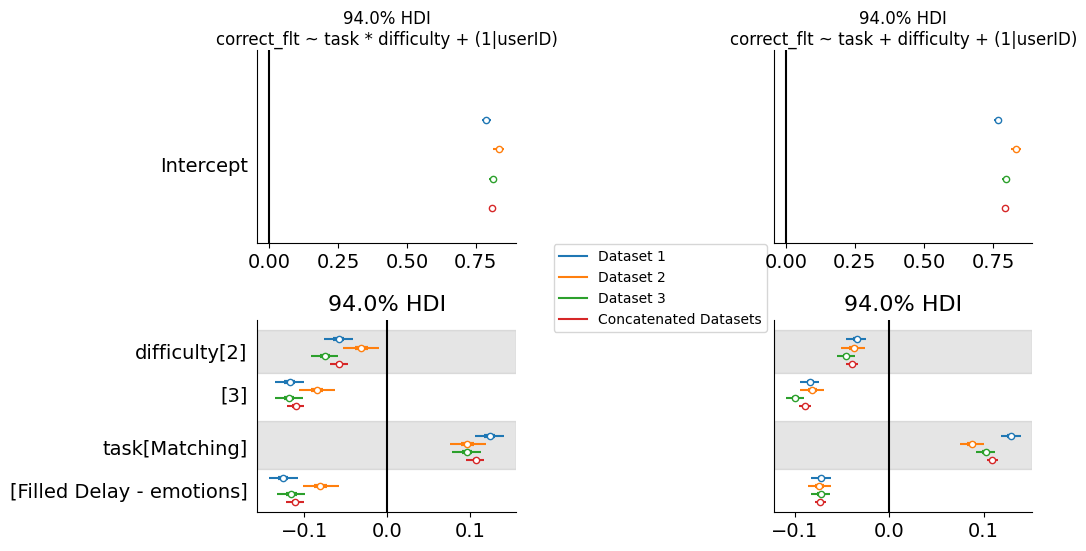

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey='row', constrained_layout=False)

plt.subplots_adjust(wspace=1., hspace=0.4)

for i in range(2):
    models = (
        list(FMP_inference_data_dict['dataset_1'].values()) +
        list(FMP_inference_data_dict['dataset_2'].values()) +
        list(FMP_inference_data_dict['dataset_3'].values()) +
        list(FMP_inference_data_dict['concat_datasets_123'].values())
    )[i::2]

    # plot 'Intercept' separately
    az.plot_forest(
        models,  # only Intercept
        model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
        var_names=["Intercept"],
        combined=True,
        ax=axs[0,i]
    )

    # Plot other variables
    az.plot_forest(
        models,
        model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
        var_names=["difficulty", "task"],
        combined=True,
        ax=axs[1,i]
    )

    axs[0,i].set_title(f"{axs[0,i].get_title()}\n{list(FMP_inference_data_dict['dataset_1'].keys())[i]}")
    
    
for i, ax in enumerate(axs.flatten()):
    ax.axvline(0, c='k')
    
    if i==0:
        # Manually adjust the legend
        legend = ax.get_legend()
        labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated datasets').replace('_', ' ').title() for x in legend.texts]
        handles = [] if legend is None else legend.legendHandles#legend_handles
        ax.legend(handles[::-1], labels[::-1], loc="lower right", bbox_to_anchor=(2., -.5))
        
    else:
        ax.legend_.remove()

sns.despine()
plt.show()


{'name': 'Arial'}
Intercept for first model
Intercept for second model
Main effects for first model
Main effects for second model


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/171149034.py:166: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles
/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/171149034.py:174: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles


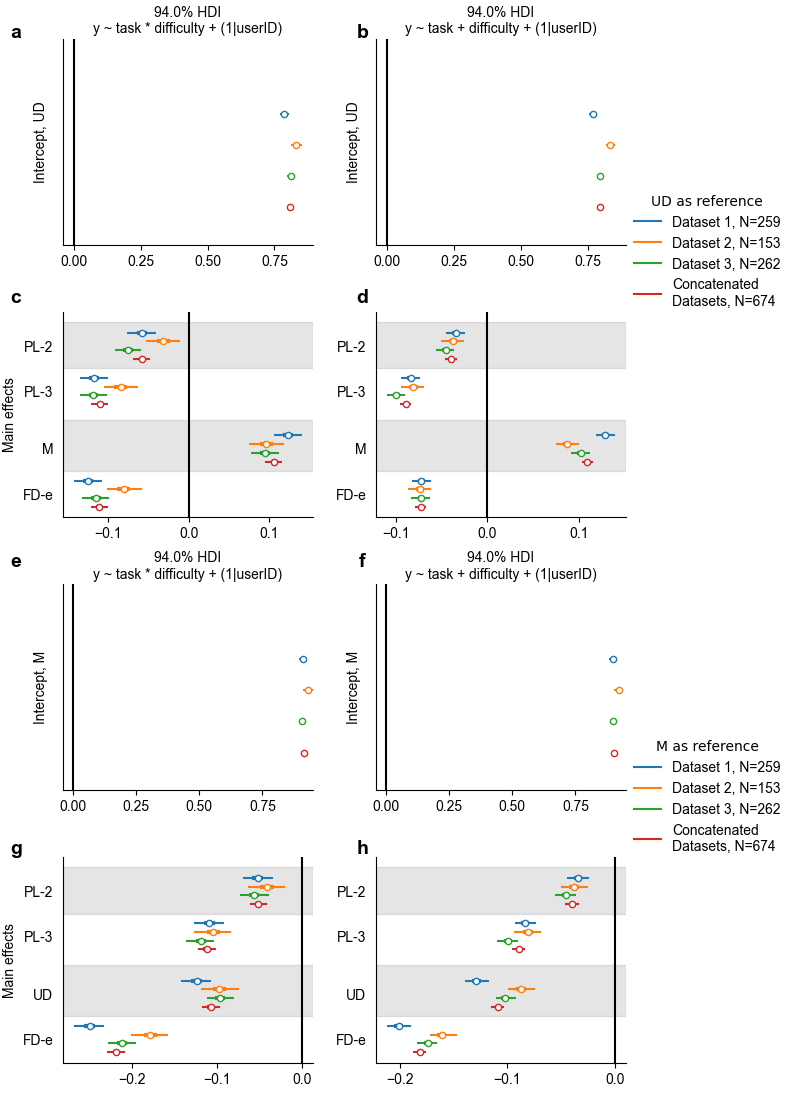

In [7]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 28#16
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.97), weight="bold", size=font_size)
c.add_text("b", Point(.52-0.06, 0.97), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.73), weight="bold", size=font_size)
c.add_text("d", Point(.52-0.06, 0.73), weight="bold", size=font_size)
c.add_text("e", Point(.02, 0.49), weight="bold", size=font_size)
c.add_text("f", Point(.52-0.06, 0.49), weight="bold", size=font_size)
c.add_text("g", Point(.02, 0.23), weight="bold", size=font_size)
c.add_text("h", Point(.52-0.06, 0.23), weight="bold", size=font_size)
# c.add_text("d", Point(.49, 0.49), weight="bold", size=font_size)
           
# titles
titles = ["Intercept for first model", "Intercept for second model", 
          "Main effects for first model", "Main effects for second model"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
# c.add_text(titles[1], Point(.55, 0.48), size=font_size)
for title in titles:
    print(title)


left_offset = 1.6
top_offset = 1
bottom_offset = 1.#1.2

hsb=1.7
vsb=1.6

# ### GRID
# # top row
c.add_grid(["intercept_1", "intercept_2", "main_effect_1", "main_effect_2"]+["intercept_1_FM", "intercept_2_FM", "main_effect_1_FM", "main_effect_2_FM"], 4, 
           Point(left_offset, bottom_offset, "cm"), Point(a-4.1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")


# ### plot
## top
for i in range(2):
    models = (
        list(FMP_inference_data_dict['dataset_1'].values()) +
        list(FMP_inference_data_dict['dataset_2'].values()) +
        list(FMP_inference_data_dict['dataset_3'].values()) +
        list(FMP_inference_data_dict['concat_datasets_123'].values())
    )[i::2]

    # Plot 'Intercept' separately
    az.plot_forest(
        models,  # Only Intercept
        model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
        var_names=["Intercept"],
        combined=True,
        ax=c.ax(f"intercept_{i+1}")
    )
    
#     c.ax(f"intercept_{i+1}").axvline(0, c='k')
    # change the title
    c.ax(f"intercept_{i+1}").set_title(f"{c.ax(f'intercept_{i+1}').get_title()}\n{list(FMP_inference_data_dict['dataset_1'].keys())[i].replace('correct_flt','y')}")

    # go over the y ticks to change them and clean them
    c.ax(f"intercept_{i+1}").set_yticklabels([''])
    # instead add a label
    c.ax(f"intercept_{i+1}").set_ylabel('Intercept, UD')

    
    # Plot other variables
    az.plot_forest(
        models,
        model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
        var_names=["difficulty", "task"],
        combined=True,
        ax=c.ax(f"main_effect_{i+1}"),
    )
    
    # remove legend
    c.ax(f"main_effect_{i+1}").legend_.remove()

    # remove the title
    c.ax(f"main_effect_{i+1}").set_title("")
    
    # update the labels
    c.ax(f"main_effect_{i+1}").set_yticklabels([
        ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
        for x in c.ax(f"main_effect_{i+1}").get_yticklabels()
    ])
    
### FM as baseline
for i in range(2):
    models = (
        list(FMP_inference_baselineFM_data_dict['dataset_1'].values()) +
        list(FMP_inference_baselineFM_data_dict['dataset_2'].values()) +
        list(FMP_inference_baselineFM_data_dict['dataset_3'].values()) +
        list(FMP_inference_baselineFM_data_dict['concat_datasets_123'].values())
    )[i::2]

    # plot 'Intercept' separately
    az.plot_forest(
        models,  # only Intercept
        model_names=[f'{f}' for f in FMP_inference_baselineFM_data_dict.keys()],
        var_names=["Intercept"],
        combined=True,
        ax=c.ax(f"intercept_{i+1}_FM")
    )
    
    # keep the same title as in the other panels
    c.ax(f"intercept_{i+1}_FM").set_title(f"{c.ax(f'intercept_{i+1}').get_title()}")

    # go over the y ticks to change them and clean them
    c.ax(f"intercept_{i+1}_FM").set_yticklabels([''])
    # instead add a label
    c.ax(f"intercept_{i+1}_FM").set_ylabel('Intercept, M')
    c.ax(f"intercept_{i+1}_FM").set_xlim((-0.04,.95))

    
    # Plot other variables
    az.plot_forest(
        models,
        model_names=[f'{f}' for f in FMP_inference_baselineFM_data_dict.keys()],
        var_names=["difficulty", "C(task, levels=base_lvl)"],
        combined=True,
        ax=c.ax(f"main_effect_{i+1}_FM"),
    )
    
    # remove legend
    c.ax(f"main_effect_{i+1}_FM").legend_.remove()

    # remove the title
    c.ax(f"main_effect_{i+1}_FM").set_title("")
    
    # update the labels
    c.ax(f"main_effect_{i+1}_FM").set_yticklabels([
        ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
        for x in c.ax(f"main_effect_{i+1}_FM").get_yticklabels()
    ])

    
c.ax(f"main_effect_1").set_ylabel('Main effects')
c.ax(f"main_effect_1_FM").set_ylabel('Main effects')

# remove legend
c.ax(f"intercept_1").legend_.remove()
c.ax(f"intercept_1_FM").legend_.remove()

# manually adjust the legend, there is some weird bug
legend = c.ax("intercept_2").get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated\ndatasets').replace('_', ' ').title()+f', N={FMP_inference_data_dict[x._text]["correct_flt ~ task * difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size}' for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
# legend on the side
c.ax("intercept_2").legend(handles[::-1], labels[::-1], title="UD as reference", loc="lower right", bbox_to_anchor=(1.67, -.37), frameon=False, )


# manually adjust the legend, there is some weird bug
legend = c.ax("intercept_2_FM").get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated\ndatasets').replace('_', ' ').title()+f', N={FMP_inference_data_dict[x._text]["correct_flt ~ task * difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size}' for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
# legend on the side
c.ax("intercept_2_FM").legend(handles[::-1], labels[::-1], title="M as reference", loc="lower right", bbox_to_anchor=(1.67, -.37), frameon=False, )


for ax in c.axes.values():
    sns.despine(ax=ax)
    # add a reference
    ax.axvline(0, c='k')



# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_1.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_1.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 2
[top](#top)

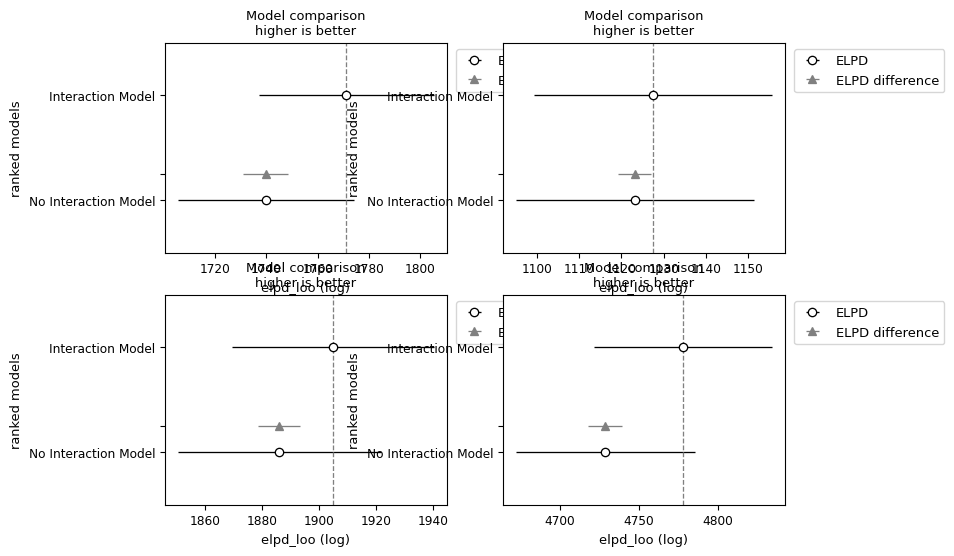

In [8]:
fig, axs = plt.subplots(2,2, figsize=(8,6))

for d, ax in zip(df_FMP_model_compare['dataset'].unique(), axs.flatten()):
    
    az.plot_compare(df_FMP_model_compare.loc[df_FMP_model_compare['dataset']==d].set_index('model_name'), 
                    insample_dev=False, ax=ax)
    
    

{'name': 'Arial'}
dataset_1
dataset_2
dataset_3
concat_datasets_123


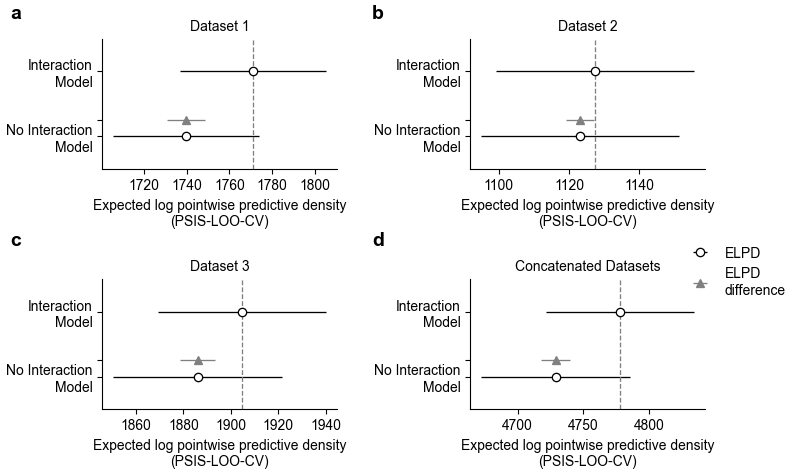

In [9]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 12
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.97), weight="bold", size=font_size)
c.add_text("b", Point(.48, 0.97), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.49), weight="bold", size=font_size)
c.add_text("d", Point(.48, 0.49), weight="bold", size=font_size)
           
# titles
titles = df_FMP_model_compare.dataset.unique()
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 2.6
top_offset = 1
bottom_offset = 1.6

hsb=2.8
vsb=3.4

# ### GRID
# # top row
c.add_grid(list(df_FMP_model_compare.dataset.unique()), 2, 
           Point(left_offset, bottom_offset, "cm"), Point(a-2.1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")


### plot
for d in df_FMP_model_compare['dataset'].unique():
    az.plot_compare(df_FMP_model_compare.loc[df_FMP_model_compare['dataset']==d].set_index('model_name'), 
                    plot_ic_diff=True, insample_dev=False, ax=c.ax(d))
    
    # remove legend
    if d !='concat_datasets_123':
        c.ax(d).legend_.remove()
    c.ax(d).set_xlabel('Expected log pointwise predictive density\n(PSIS-LOO-CV)')
    c.ax(d).set_ylabel('')
    c.ax(d).set_yticklabels([x.get_text().replace(' Model', '\nModel') for x in c.ax(d).get_yticklabels()])
    
    c.ax(d).set_title(d.replace('concat_datasets_123', 'concatenated datasets').replace('_', ' ').title())


# manually adjust the legend, there is some weird bug
handles, labels = c.ax("concat_datasets_123").get_legend_handles_labels()
# legend on the side
c.ax("concat_datasets_123").legend(handles, [x.replace(' ', '\n') for x in labels], 
                                   loc="upper right", bbox_to_anchor=(1.4, 1.35), frameon=False, )


for ax in c.axes.values():
    sns.despine(ax=ax)


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_2.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_2.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 3
[top](#top)

/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/3227463420.py:21: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles#legend_handles


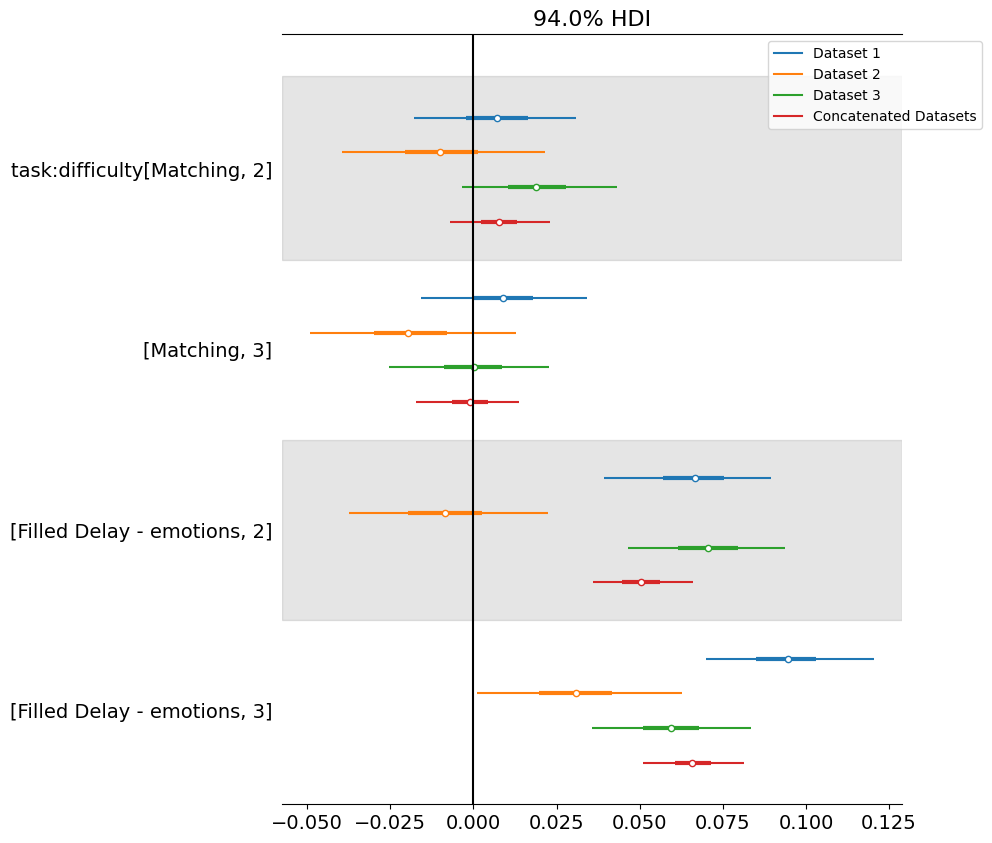

In [10]:
fig, ax = plt.subplots(figsize=(8, 10))


az.plot_forest(
    (list(FMP_inference_data_dict['dataset_1'].values())+\
    list(FMP_inference_data_dict['dataset_2'].values())+\
    list(FMP_inference_data_dict['dataset_3'].values())+\
    list(FMP_inference_data_dict['concat_datasets_123'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated datasets').replace('_',' ').title() for x in legend.texts]
handles = [] if legend is None else legend.legendHandles#legend_handles
ax.legend(handles[::-1], labels[::-1], loc="upper right", bbox_to_anchor=(1.14, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

#### With FM as reference level

{'name': 'Arial'}
Interaction terms across the four datasets with FM set as reference


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/3803779005.py:63: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles


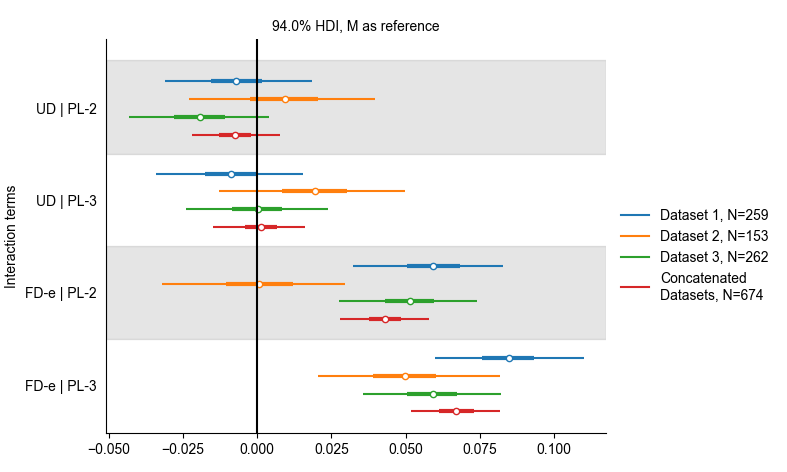

In [11]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 12
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
# c.add_text("a", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("b", Point(.52, 0.97), weight="bold", size=font_size)
           
# titles
titles = ["Interaction terms across the four datasets with FM set as reference"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 2.7
top_offset = 1
bottom_offset = 1.#1.2

hsb=.7
vsb=.3

# ### GRID
# # top row
c.add_grid(["interactions_FM"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-4.6, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"))


#### Plot with FM as reference level

az.plot_forest(
    (list(FMP_inference_baselineFM_data_dict['dataset_1'].values())+\
    list(FMP_inference_baselineFM_data_dict['dataset_2'].values())+\
    list(FMP_inference_baselineFM_data_dict['dataset_3'].values())+\
    list(FMP_inference_baselineFM_data_dict['concat_datasets_123'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_inference_baselineFM_data_dict.keys()],
    var_names=["C(task, levels=base_lvl):difficulty"],
    combined=True,
    ax=c.ax("interactions_FM")
)

# # manually adjust the legend, there is some weird bug
legend = c.ax("interactions_FM").get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated\ndatasets').replace('_', ' ').title()+f', N={FMP_inference_baselineFM_data_dict[x._text]["correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size}' for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
# # and switch the order of the vars in the legend as it it reversed for some reason
# # legend on the side
c.ax("interactions_FM").legend(handles[::-1], labels[::-1], loc="upper right", bbox_to_anchor=(1.35, .6), frameon=False)

# update y ticks
c.ax("interactions_FM").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions_FM").get_yticklabels()
])

c.ax("interactions_FM").set_ylabel('Interaction terms')
# change the title
c.ax(f"interactions_FM").set_title(f"{c.ax(f'interactions_FM').get_title()}, M as reference")

for ax in c.axes.values():
    sns.despine(ax=ax)
    ax.axvline(0, c='k')



# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_3.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_3.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 4
[top](#top)

### Bayesian inference - FMP select top 50% participants
[top](#top)

Original UD acc: 0.81 ± 0.39
Selecting 337 participants
After selection:
dataset_1
  Unfilled Delay:
          0.85
  Filled Delay - emotions:
          0.79
dataset_2
  Unfilled Delay:
          0.89
  Filled Delay - emotions:
          0.83
dataset_3
  Unfilled Delay:
          0.85
  Filled Delay - emotions:
          0.79
concat_datasets_123
  Unfilled Delay:
          0.86
  Filled Delay - emotions:
          0.80


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


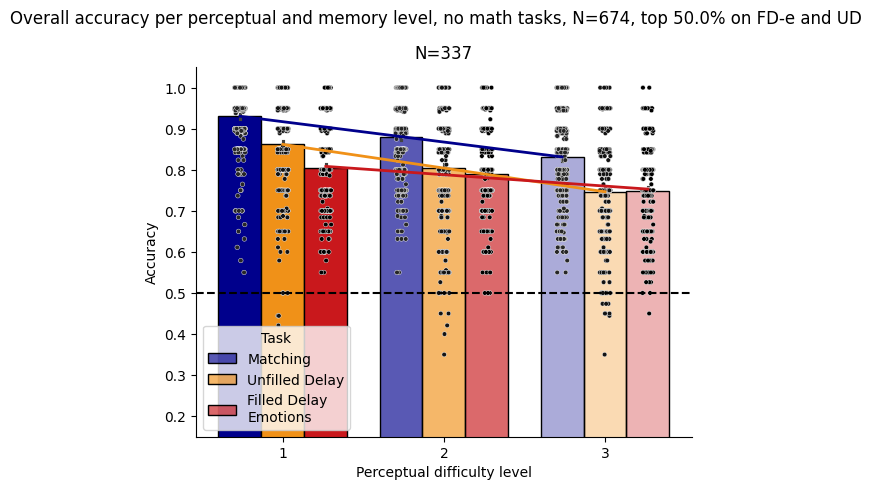

In [12]:
# create a special data
data = df_dic['concat_datasets_123'].copy()

# get the mean
mu_UD = data.loc[(data["task"]=="Unfilled Delay")&(data["difficulty"]==1)].correct_flt.mean()
sd_UD = data.loc[(data["task"]=="Unfilled Delay")&(data["difficulty"]==1)].correct_flt.std()


# print the original acc
print(f"Original UD acc: {mu_UD:.2f} ± {sd_UD:.2f}")

# select participants, take top 50 %
top_thr = 0.5
matched_acc_ptc = data.loc[data["task"] == "Filled Delay - emotions"].groupby(['userID']).correct_flt.mean().sort_values()[np.ceil(674*(1-top_thr)).astype(int):].index.values

print(f"Selecting {len(matched_acc_ptc)} participants")
print("After selection:")

# select only specific datasets and prepare them
datasets2fit = ['dataset_1', 'dataset_2', 'dataset_3', 'concat_datasets_123']

for f in datasets2fit:
    data=None
    data = df_dic[f].copy()
    print(f)
    print(f"""  Unfilled Delay:
          {data.loc[data["userID"].isin(matched_acc_ptc)&(data["task"] == "Unfilled Delay")&(data["difficulty"] == 1)].correct_flt.mean():.2f}""")

    print(f"""  Filled Delay - emotions:
          {data.loc[data["userID"].isin(matched_acc_ptc)&(data["task"] == "Filled Delay - emotions")&(data["difficulty"] == 1)].correct_flt.mean():.2f}""")



fig, ax = plt.subplots(1,1)

plot_FMP_results_slopes(data.loc[data['userID'].isin(matched_acc_ptc)], ax, get_flattened_palette(hue_order))
            
plt.suptitle(f"Overall accuracy per perceptual and memory level, no math tasks, N={data.userID.unique().size}, top {top_thr*100}% on FD-e and UD", 
             y=1.0)


# plt.savefig(os.path.join('/Users/jan/Downloads', 'fig2_FMP.pdf'), dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# Load the dictionary from the pickle file
with open(opj(path_data,'model_inference_data', f'FMP_Floor_top{int(top_thr*100)}_FDe_inference_data_dict.pkl'), 'rb') as f:
    FMP_floor_inference_data_dict = pickle.load(f)

{'name': 'Arial'}
Overall accuracy per perceptual and memory level, no math tasks, N=674


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than need

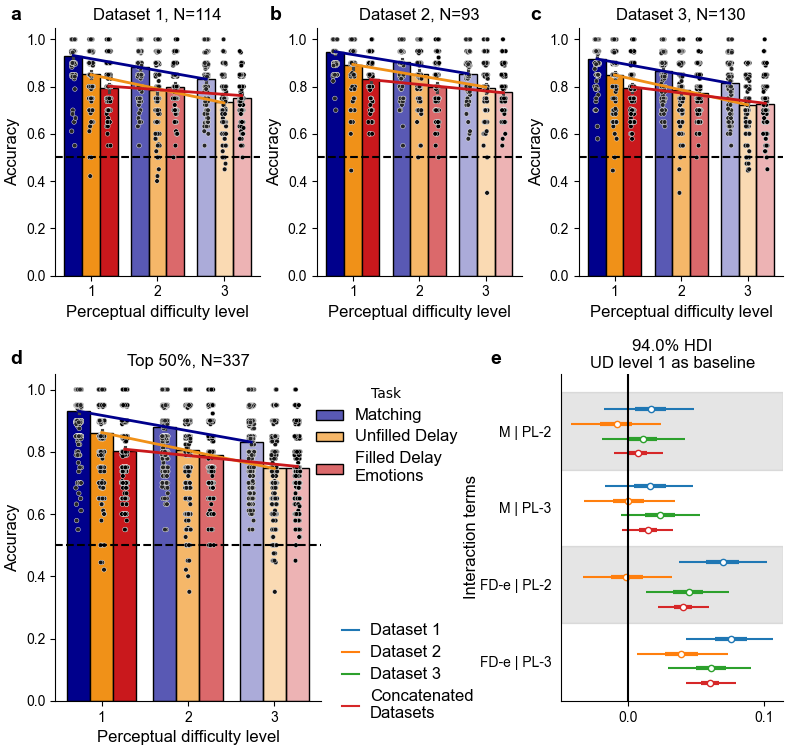

In [14]:
#######################
# define canvas

from cand import Canvas, Vector, Point
import matplotlib.ticker as ticker


##### deal with data and colours
# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

#######


# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 19
# rot = 15
c = Canvas(a, b, "cm")

# set font
# c.set_font("Helvetica", size=10)
c.set_font("Arial", size=12, ticksize=legend_size)

# letters
# c.add_text("A", Point(.05, 0.98), weight="bold")
# c.add_text("A)", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("B)", Point(.02, 0.5), weight="bold", size=font_size)

c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.35, 0.98), weight="bold", size=font_size)
c.add_text("c", Point(.68, 0.98), weight="bold", size=font_size)
c.add_text("d", Point(.02, 0.52), weight="bold", size=font_size)
c.add_text("e", Point(.63, 0.52), weight="bold", size=font_size)
           
# titles
titles = [f"Overall accuracy per perceptual and memory level, no math tasks, N={df_dic['concat_datasets_123'].userID.unique().size}"]
# c.add_text(titles[0], Point(.5, 0.96), size=font_size)

for title in titles:
    print(title)

# ### GRID
# # top row, panel A
top_offset = .7
bottom_offset = 1.2
left_offset = 1.4
hsb = 1 #half_space_between - horizontal
vsb = 1.45 #half_space_between - vertical
middle_h = 9.5
middle_v = 13 # between the bottom two
vsb_bottom = 1.25 # space between the bottom two

# add a 1x3 grid
c.add_grid(["FMP", "FMP_S", "FMP_order"], 1, Point(left_offset, middle_h+2.5, "cm"), Point(a-.1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="tasks")
# add a 1x1 grid
c.add_grid(["combined"], 1, Point(left_offset, bottom_offset, "cm"), Point(middle_v-3.6-vsb_bottom, middle_h, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["interactions"], 1, Point(middle_v+vsb_bottom, bottom_offset, "cm"), Point(a-.1, middle_h, "cm"), spacing=Vector(vsb, hsb, "cm"))


######### panel A
plot_FMP_results_slopes(df_dic['dataset_1'].loc[df_dic['dataset_1']['userID'].isin(matched_acc_ptc)], c.ax("FMP"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 1, ')
plot_FMP_results_slopes(df_dic['dataset_2'].loc[df_dic['dataset_2']['userID'].isin(matched_acc_ptc)], c.ax("FMP_S"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 2, ')
plot_FMP_results_slopes(df_dic['dataset_3'].loc[df_dic['dataset_3']['userID'].isin(matched_acc_ptc)], c.ax("FMP_order"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 3, ')

######### bottom row
plot_FMP_results_slopes(df_dic['concat_datasets_123'].loc[df_dic['concat_datasets_123']['userID'].isin(matched_acc_ptc)], c.ax("combined"), get_flattened_palette(hue_order), 
                        legend_kwargs={"loc":"upper right", "bbox_to_anchor":(1.56, 1), "frameon":False}, title=f'Top {int(top_thr*100)}%, ')

# add y-axis to start at 0
for ax_name in ["FMP", "FMP_S", "FMP_order", "combined"]:
    c.ax(ax_name).set_ylim(bottom=0)
    
### plot interactions

az.plot_forest(
    (list(FMP_floor_inference_data_dict['dataset_1'].values())+\
    list(FMP_floor_inference_data_dict['dataset_2'].values())+\
    list(FMP_floor_inference_data_dict['dataset_3'].values())+\
    list(FMP_floor_inference_data_dict['concat_datasets_123'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_floor_inference_data_dict.keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=c.ax("interactions")
)

# # manually adjust the legend, there is some weird bug
legend = c.ax("interactions").get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated\ndatasets').replace('_', ' ').title() for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
# # and switch the order of the vars in the legend as it it reversed for some reason
# # legend on the side
c.ax("interactions").legend(handles[::-1], labels[::-1], loc="lower left", bbox_to_anchor=(-1.04, -.1), handlelength=1.2, frameon=False)

# update y ticks
c.ax("interactions").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions").get_yticklabels()
])

c.ax("interactions").set_ylabel('Interaction terms', labelpad=0.5)
c.ax("interactions").axvline(0, c='k')
# c.ax("interactions").set_xlabel('')

# add title
c.ax("interactions").set_title(f'{c.ax("interactions").get_title()}\nUD level 1 as baseline')

for ax in c.axes.values():
    sns.despine(ax=ax)
#     ax.axvline(0, c='k')
        

    
# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_4.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_4.pdf'), dpi=300)#, bbox_inches="tight")


## SI Figure 5
[top](#top)

### Check for learning (differences if a task comes fist vs another place)

In [15]:
# Load the dictionary from the pickle file
with open(opj(path_data,'model_inference_data', 'FMP_learning_first_inference_data_dict.pkl'), 'rb') as f:
    FMP_learning_inference_data_dict = pickle.load(f)

In [16]:
FMP_learning_inference_data_dict

{'concat_datasets_123': {'Matching': {'correct_flt ~ task * difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   	> observed_data,
   'correct_flt ~ task + difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   	> observed_data},
  'Unfilled Delay': {'correct_flt ~ task * difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   	> observed_data,
   'correct_flt ~ task + difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   	> observed_data},
  'Filled Delay - emotions': {'correct_flt ~ task * difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   	> observed_data,
   'correct_flt ~ task + difficulty + (1|userID)': Inference data with groups:
   	> posterior
   	> log_likelihood
   	> sample_stats
   

In [17]:
model_name_dic = {
    'correct_flt ~ task * difficulty + (1|userID)':'Interaction Model',
    'correct_flt ~ task + difficulty + (1|userID)':'No Interaction Model',   
}

FMP_model_compare_dic = {}

for i, tsk in enumerate(hue_order):
    # create the model comparison
    df_compare_tmp = az.compare(FMP_learning_inference_data_dict['concat_datasets_123'][tsk])

    # rename the models
    df_compare_tmp = df_compare_tmp.reset_index().rename(columns={'index':'formula'})
    df_compare_tmp['model_name'] = df_compare_tmp['formula'].replace(model_name_dic)
    # add dataset label
    df_compare_tmp['starting_task'] = tsk

    FMP_model_compare_dic[tsk] = df_compare_tmp.copy()
    
df_FMP_model_compare = pd.concat(FMP_model_compare_dic).reset_index(drop=True)
# add statistical significance
for p_val in [0.05, 0.01, 0.001]:
    df_FMP_model_compare[f'two-tail_{str(p_val).split(".")[-1]}'] = df_FMP_model_compare['elpd_diff'] > df_FMP_model_compare['dse']*get_z_value(p_val)

df_FMP_model_compare

,formula,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,model_name,starting_task,two-tail_05,two-tail_01,two-tail_001
0,correct_flt ~ task * difficulty + (1|userID),0,1637.957224,191.077675,0.000000,0.860405,32.456985,0.000000,False,log,Interaction Model,Matching,False,False,False
1,correct_flt ~ task + difficulty + (1|userID),1,1619.364570,185.958249,18.592653,0.139595,32.722804,7.208496,False,log,No Interaction Model,Matching,True,True,False
2,correct_flt ~ task * difficulty + (1|userID),0,1604.355479,195.029951,0.000000,0.841945,33.591814,0.000000,False,log,Interaction Model,Unfilled Delay,False,False,False
3,correct_flt ~ task + difficulty + (1|userID),1,1586.498811,189.919531,17.856668,0.158055,33.615893,7.249459,False,log,No Interaction Model,Unfilled Delay,True,False,False
4,correct_flt ~ task * difficulty + (1|userID),0,1528.767363,182.728465,0.000000,0.743264,31.646744,0.000000,False,log,Interaction Model,Filled Delay - emotions,False,False,False
5,correct_flt ~ task + difficulty + (1|userID),1,1522.812513,177.820862,5.954849,0.256736,31.853660,4.965084,False,log,No Interaction Model,Filled Delay - emotions,False,False,False


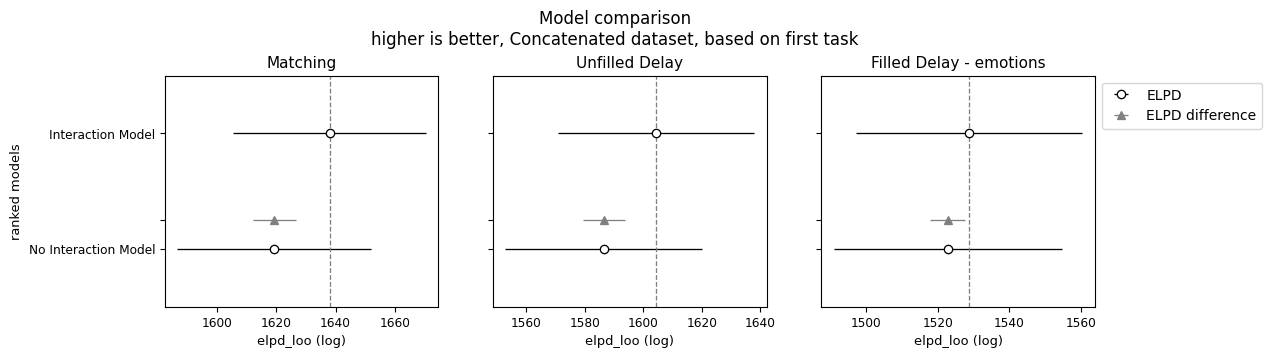

In [18]:
fig, axs = plt.subplots(1,3, figsize=(12,3), sharey=True, constrained_layout=False)
plt.subplots_adjust(hspace=0.8)

for (i,tsk),ax in zip(enumerate(df_FMP_model_compare['starting_task'].unique()), axs.flatten()):
    az.plot_compare(df_FMP_model_compare.loc[df_FMP_model_compare['starting_task']==tsk].set_index('model_name'), 
                    insample_dev=False, ax=ax)
    
    if i==2:
        ax.legend(bbox_to_anchor=(1,1))
    else:
        ax.legend_.remove()

    if i!=0:
        ax.set_ylabel('')
        
    t = ax.get_title()
#     ax.set_title(f.replace('concat_datasets_123', 'concatenated datasets').replace('_',' ').title(), fontsize=11)
    ax.set_title(tsk, fontsize=11)
    
plt.suptitle(f"{t}, Concatenated dataset, based on first task", y=1.1)
plt.show()

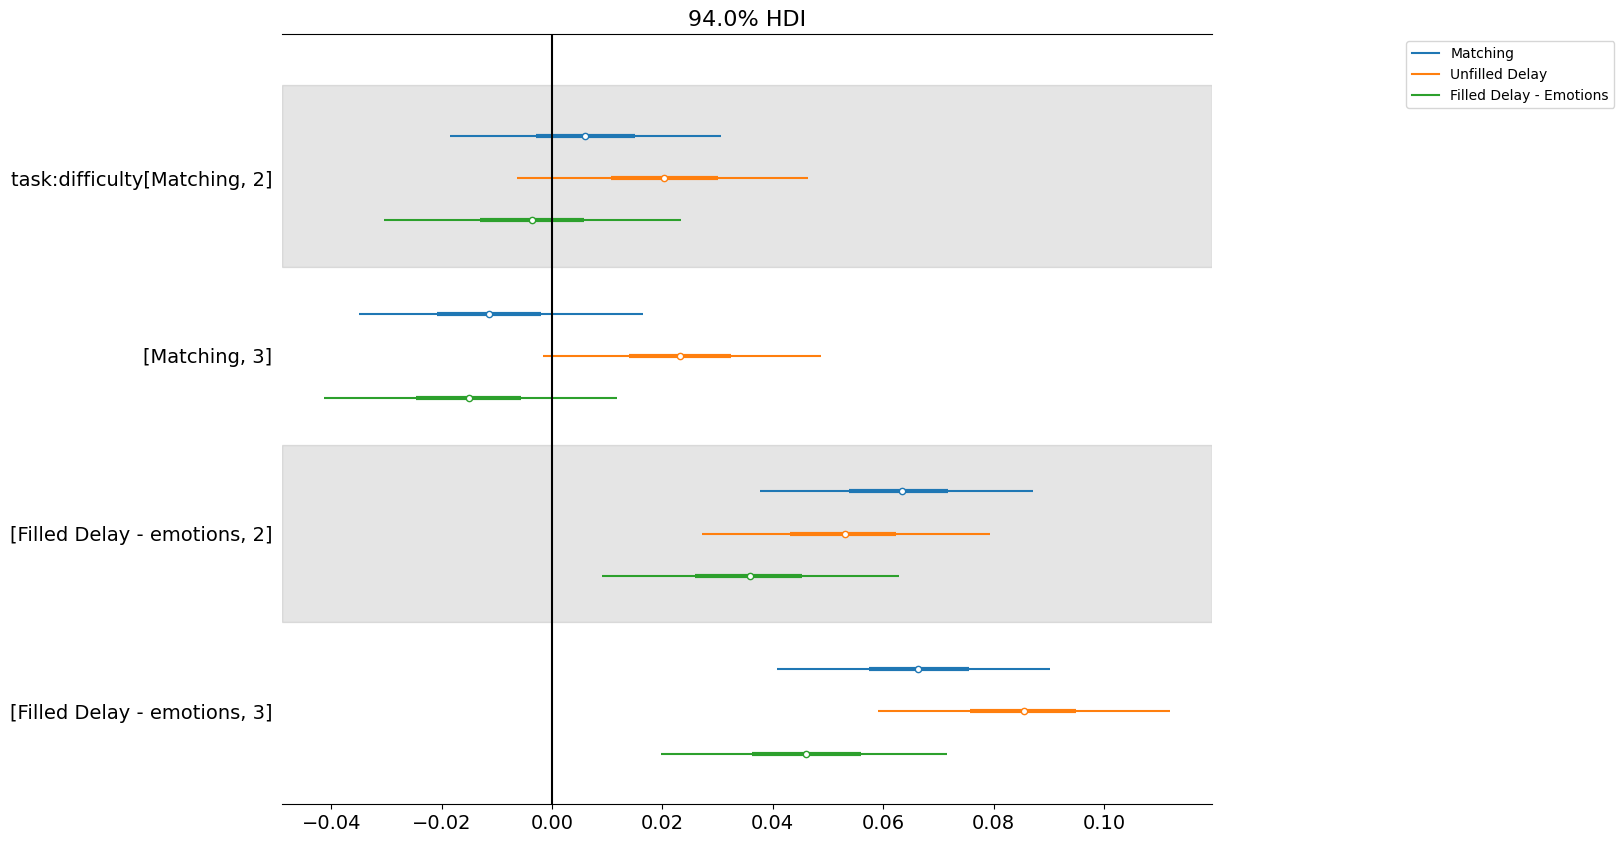

In [19]:

fig, ax = plt.subplots(figsize=(12, 10))

az.plot_forest(
        (list(FMP_learning_inference_data_dict['concat_datasets_123']['Matching'].values())+\
         list(FMP_learning_inference_data_dict['concat_datasets_123']['Unfilled Delay'].values())+\
         list(FMP_learning_inference_data_dict['concat_datasets_123']['Filled Delay - emotions'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_learning_inference_data_dict['concat_datasets_123'].keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
# plt.show()


# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated datasets').replace('_',' ').title() for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles[::-1], labels[::-1], loc="upper right", bbox_to_anchor=(1.44, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

### Check whether accuracy on the first and other tasks differs
[top](#top)

In [20]:
for f in ['dataset_1', 'dataset_1b', 'dataset_2', 'dataset_3', 'dataset_4', 'dataset_5', 'concat_datasets_123']:
    # add labels to the order, NOTE that math will have an uknown label (third), others will not
    df_dic[f]['task_order'] = np.select(
        [
            df_dic[f]['order'].isin([1, 2, 3]), 
            df_dic[f]['order'].isin([4, 5, 6]), 
            df_dic[f]['order'].isin([10, 11, 12])
        ], 
        ['first', 'second', 'last'], default='third')


<Axes: xlabel='task', ylabel='correct_flt'>

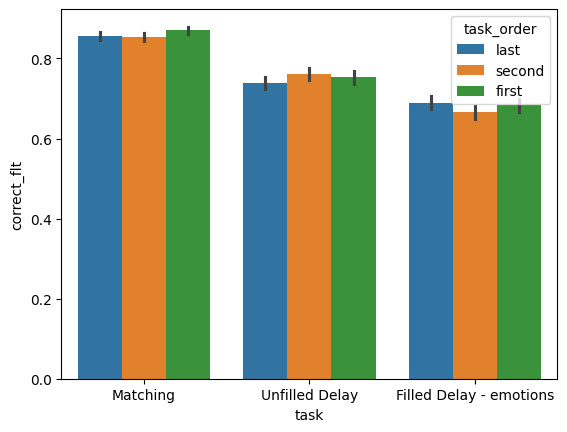

In [21]:
sns.barplot(df_dic['concat_datasets_123'].groupby(['userID', 'task', 'task_order']).correct_flt.mean().reset_index(), 
            x="task", y="correct_flt", hue="task_order", order=hue_order)



#### Do stats

In [22]:

results = []
anova_results = []

# go over each task
for tsk in hue_order:
    # get mean acc per ptc and position
    tmp_df = df_dic['concat_datasets_123'].loc[df_dic['concat_datasets_123']["task"]==tsk].groupby(['userID', 'task_order'])['correct_flt'].mean().reset_index()


    # do paired t-test only for first/last
    ttest_res = pg.ttest(tmp_df.loc[tmp_df['task_order']=='first', 'correct_flt'], 
                         tmp_df.loc[tmp_df['task_order']=='last', 'correct_flt'], paired=False)
    ttest_res['task'] = tsk
    ttest_res['star_gazing'] = ttest_res['p-val'].apply(star_gazing)
    results.append(ttest_res)

    # do anova including all the levels
    anova_res = pg.anova(dv='correct_flt', between='task_order', data=tmp_df)
    anova_res['task'] = tsk
    anova_res['star_gazing'] = anova_res['p-unc'].apply(star_gazing)
    anova_results.append(anova_res)

# combine all results
ttest_results = pd.concat(results, ignore_index=True)

ttest_results

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,task,star_gazing
0,1.988768,450.883727,two-sided,0.047331,"[0.0, 0.03]",0.185550,0.7,0.510270,Matching,*
1,1.253459,451.999769,two-sided,0.210687,"[-0.01, 0.04]",0.117626,0.223,0.239641,Unfilled Delay,
2,-0.529661,425.960401,two-sided,0.596623,"[-0.03, 0.02]",0.051205,0.123,0.082560,Filled Delay - emotions,


In [23]:
pd.concat(anova_results, ignore_index=True)

,Source,ddof1,ddof2,F,p-unc,np2,task,star_gazing
0,task_order,2,671,3.197448,0.041490,0.009440,Matching,*
1,task_order,2,671,2.188645,0.112868,0.006481,Unfilled Delay,
2,task_order,2,664,2.119501,0.120903,0.006344,Filled Delay - emotions,


In [24]:
posthoc = pg.pairwise_tukey(
    data=df_dic['concat_datasets_123'].loc[df_dic['concat_datasets_123']["task"]=="Matching"].groupby(['userID', 'task_order'])['correct_flt'].mean().reset_index(), 
    dv='correct_flt', between='task_order', effsize='cohen',
)

posthoc['star_gazing'] = posthoc['p-tukey'].apply(star_gazing)

posthoc

,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,first,last,0.870610,0.856608,0.014002,0.007152,1.957837,0.123619,0.185550,
1,first,second,0.870610,0.853482,0.017127,0.007276,2.353826,0.049387,0.228191,*
2,last,second,0.856608,0.853482,0.003126,0.007292,0.428663,0.903704,0.039301,


### Plot with stats

{'name': 'Arial'}
FMP results when participants start with a particular task, N=674


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than need

This patch could not be labelled, h=0, last, x=0
This patch could not be labelled, h=0, second, x=0
This patch could not be labelled, h=0, first, x=0


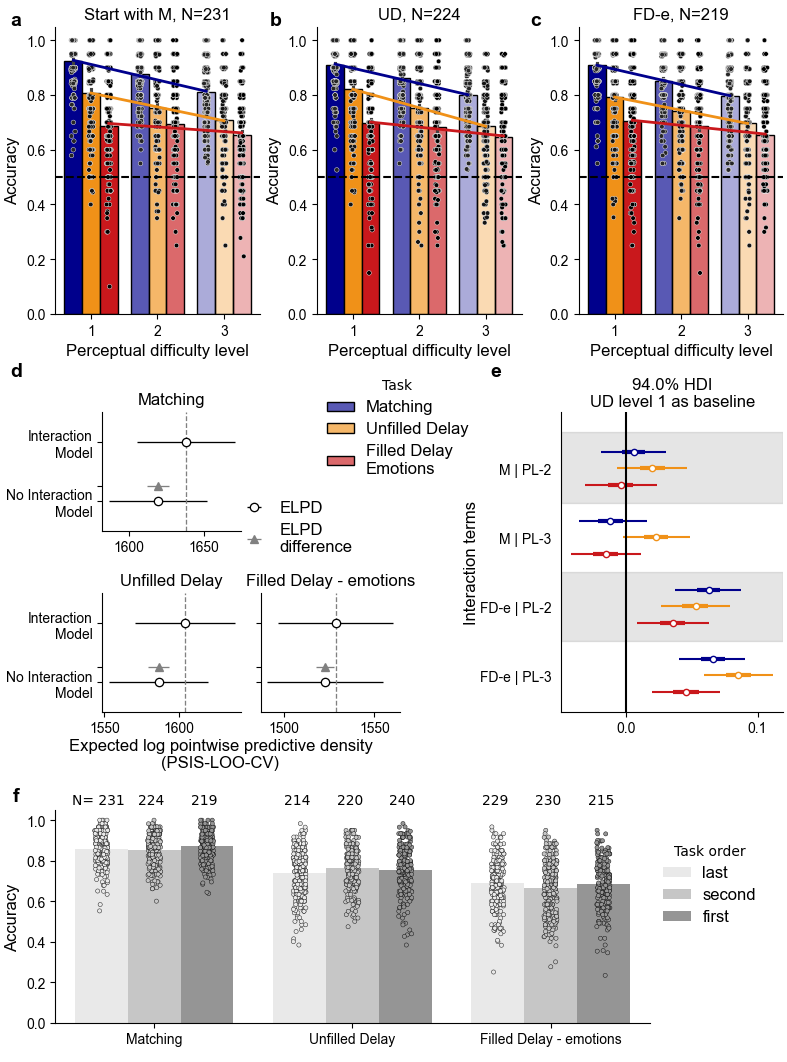

In [25]:
#######################
# define canvas

from cand import Canvas, Vector, Point
import matplotlib.ticker as ticker


##### deal with data and colours
# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

#######


# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
extra = 7
a = 20
b = 20+extra
# rot = 15
c = Canvas(a, b, "cm")

# set font
# c.set_font("Helvetica", size=10)
c.set_font("Arial", size=12, ticksize=legend_size)

# letters
# c.add_text("A", Point(.05, 0.98), weight="bold")
# c.add_text("A)", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("B)", Point(.02, 0.5), weight="bold", size=font_size)

c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.35, 0.98), weight="bold", size=font_size)
c.add_text("c", Point(.68, 0.98), weight="bold", size=font_size)
c.add_text("d", Point(.02, 0.65), weight="bold", size=font_size)
c.add_text("e", Point(.63, 0.65), weight="bold", size=font_size)
c.add_text("f", Point(.02, 0.25), weight="bold", size=font_size)
           
# titles
titles = [f"FMP results when participants start with a particular task, N={df_dic['concat_datasets_123'].userID.unique().size}"]
# c.add_text(titles[0], Point(.5, 0.96), size=font_size)

for title in titles:
    print(title)

# ### GRID
# # top row, panel A
top_offset = .7
bottom_offset = 1.#9
second_bottom_offset = 1.9 + extra
left_offset = 1.4
hsb = 1 #half_space_between - horizontal
vsb = 1.45 #half_space_between - vertical
middle_h = 9.5 + extra
middle_v = 13 # between the bottom two
vsb_bottom = 1.25 # space between the bottom two

# add a 1x3 grid
c.add_grid(hue_order, 1, Point(left_offset, middle_h+2.5, "cm"), Point(a-.1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="tasks")
# add a 1x1 grid
c.add_grid(['Matching_looc', 'empty','Unfilled Delay_looc', 'Filled Delay - emotions_looc'], 2, Point(left_offset+1.2, second_bottom_offset, "cm"), Point(middle_v-1.6-vsb_bottom, middle_h, "cm"), spacing=Vector(.5, 1.6, "cm"), unitname="grid")
c.add_grid(["interactions"], 1, Point(middle_v+vsb_bottom, second_bottom_offset, "cm"), Point(a-.1, middle_h, "cm"), spacing=Vector(vsb, hsb, "cm"))
c.add_grid(["learning"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-3.5, second_bottom_offset-2.5, "cm"), spacing=Vector(vsb, hsb, "cm"))

######### top row
dic_ptc = {}
# abbreviations = [''.join(word[0] for word in label.replace('-', '').split()) for label in hue_order]
for i, tsk in enumerate(hue_order):

    # choose the participants who start with this task
    matched_acc_ptc = set(df_dic['concat_datasets_123'].loc[(df_dic['concat_datasets_123']['order'].isin([1,2,3]))&(df_dic['concat_datasets_123']['task']==tsk), 'userID'])

    dic_ptc[tsk]=matched_acc_ptc
    
    #
    if tsk == "Matching":
        title='Start with M, '
    elif tsk == "Unfilled Delay":
        title='UD, '
    else:
        title='FD-e, '
    plot_FMP_results_slopes(df_dic['concat_datasets_123'].loc[df_dic['concat_datasets_123']['userID'].isin(list(matched_acc_ptc))], 
                            c.ax(f"{tsk}"), get_flattened_palette(hue_order), title=title, plot_legend= i==1,
                            legend_kwargs={"loc":"upper right", "bbox_to_anchor":(.8, -.18), "frameon":False},
                           )




# add y-axis to start at 0
for ax_name in hue_order:
    c.ax(ax_name).set_ylim(bottom=0)


######### second bottom row
for tsk in df_FMP_model_compare['starting_task'].unique():
    az.plot_compare(df_FMP_model_compare.loc[df_FMP_model_compare['starting_task']==tsk].set_index('model_name'), 
                    plot_ic_diff=True, insample_dev=False, ax=c.ax(f"{tsk}_looc"))
    
    # remove legend
    if tsk !='Filled Delay - emotions':
        c.ax(f"{tsk}_looc").legend_.remove()
        # c.ax(f"{tsk}_looc").set_xlabel('')
        c.ax(f"{tsk}_looc").set_yticklabels([x.get_text().replace(' Model', '\nModel') for x in c.ax(f"{tsk}_looc").get_yticklabels()])
    else:
        # c.ax(f"{tsk}_looc").set_xlabel('Expected log pointwise predictive density\n(PSIS-LOO-CV)', loc='left')
        c.add_text('Expected log pointwise predictive density\n(PSIS-LOO-CV)', Point(0.28, 0.29))
        # c.ax(f"{tsk}_looc").xaxis.set_label_coords(50.0, -0.5)
        c.ax(f"{tsk}_looc").set_yticklabels([])

    c.ax(f"{tsk}_looc").set_xlabel('')
        
    
    c.ax(f"{tsk}_looc").set_ylabel('')
    # c.ax(f"{tsk}_looc").set_yticklabels([x.get_text().replace(' Model', '\nModel') for x in c.ax(f"{tsk}_looc").get_yticklabels()])
    
    c.ax(f"{tsk}_looc").set_title(tsk)

# turn off the empty space
c.ax("empty").axis("off")


# manually adjust the legend, there is some weird bug
handles, labels = c.ax("Filled Delay - emotions_looc").get_legend_handles_labels()
# legend on the side
c.ax("Filled Delay - emotions_looc").legend(handles, [x.replace(' ', '\n') for x in labels], 
                                   loc="upper right", bbox_to_anchor=(.75, 1.9), frameon=False, )
    
# ### plot interactions

az.plot_forest(
    (list(FMP_learning_inference_data_dict['concat_datasets_123']['Matching'].values())+\
    list(FMP_learning_inference_data_dict['concat_datasets_123']['Unfilled Delay'].values())+\
    list(FMP_learning_inference_data_dict['concat_datasets_123']['Filled Delay - emotions'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_learning_inference_data_dict['concat_datasets_123'].keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=c.ax("interactions"),
    colors=get_flattened_palette(hue_order)[::3],
    # legend=False,
)

# legend
c.ax("interactions").legend_.remove()

# update y ticks
c.ax("interactions").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions").get_yticklabels()
])

c.ax("interactions").set_ylabel('Interaction terms', labelpad=0.5)
c.ax("interactions").axvline(0, c='k')
# c.ax("interactions").set_xlabel('')

# add title
c.ax("interactions").set_title(f'{c.ax("interactions").get_title()}\nUD level 1 as baseline')

for ax in c.axes.values():
    sns.despine(ax=ax)
#     ax.axvline(0, c='k')


######### bottom row
# define data
data_l = None
data_l = df_dic['concat_datasets_123'].groupby(['userID', 'task', 'task_order']).correct_flt.mean().reset_index()
palette_l = sns.color_palette("Greys", n_colors=5)[:3]
sns.barplot(data_l, x="task", y="correct_flt", hue="task_order", order=hue_order, 
            ax=c.ax("learning"), 
            palette=palette_l)

stripplot = sns.stripplot(data=data_l, x="task", y="correct_flt", hue="task_order", order=hue_order,
                          edgecolor='k', palette=palette_l,
                          ax=c.ax("learning"), size=3, linewidth=0.3, legend=False, dodge=True,
                          )

c.ax("learning").legend(title="Task order",
                        loc="upper right", bbox_to_anchor=(1.2, 0.9), frameon=False, )
c.ax("learning").set_xlabel('')
c.ax("learning").set_ylabel('Accuracy')


# add N to each bar
# first get it and order by the task
df_N_per_task = data_l.groupby(['task','task_order']).size().reindex([
    ('Matching', 'first'),
    ('Matching', 'second'),
    ('Matching', 'last'),
    ('Unfilled Delay', 'first'),
    ('Unfilled Delay', 'second'),
    ('Unfilled Delay', 'last'),
    ('Filled Delay - emotions', 'first'),
    ('Filled Delay - emotions', 'second'),
    ('Filled Delay - emotions', 'last'),
]).to_frame('N').reset_index()

# now plot it
ax = c.ax("learning")
for i, bar in enumerate(ax.patches):
    h = bar.get_height()
    # I don't know since when but in April 2024, new patches are added, seems like legend,
    # and these also get labelled. To avoid that, I'm checking for their label and heigh. TODO investigate
    if bar.get_label() != '_nolegend_' or h==0:
        print(f'This patch could not be labelled, h={h}, {bar.get_label()}, x={bar.get_x()}')
        continue

    if i==0:
        N_label = f"N= {df_N_per_task.iloc[i]['N']}"
    else:
        N_label = str(df_N_per_task.iloc[i]['N'])
    ax.text(
        #             i, # bar index (x coordinate of text)
        bar.get_x() + 0.12,  # bar index (x coordinate of text)
        # h + 0.1,  # y coordinate of text
        1.1,
        str(N_label), # label
        ha='center',
        va='center',
        size=10)
    
# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_5.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_5.pdf'), dpi=300)#, bbox_inches="tight")


## SI Figure 6

### Bayesian inference - FMP cue stimulus interaction
[top](#top)

In [26]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_cue_stimulus_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_interaction_inference_data_dict = pickle.load(f)
    
with open(opj(path_data, 'model_inference_data', 'FMP_cue_stimulus_baselineFM_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_interaction_baselineFM_inference_data_dict = pickle.load(f)


FMP_cue_stim_interaction_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)']

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [27]:
FMP_cue_stim_interaction_inference_data_dict.keys()

dict_keys(['correct_flt ~ task * difficulty + (1|userID)', 'correct_flt ~ task + difficulty + (1|userID)', 'correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)', 'correct_flt ~ task * difficulty * target_loc_simple + (1|userID)'])

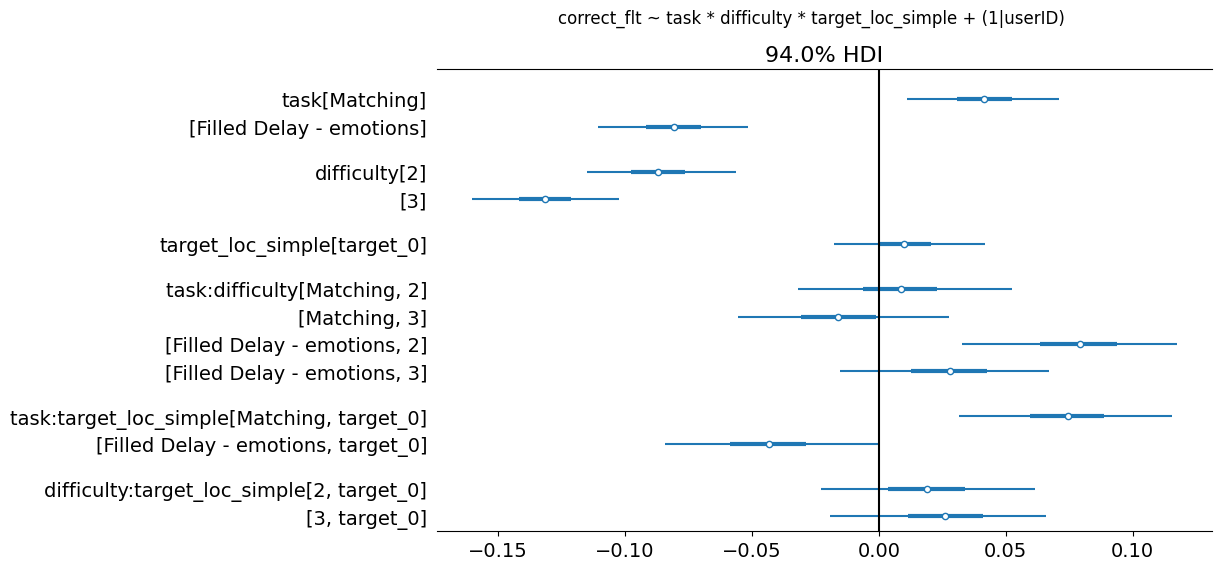

In [28]:
formula = 'correct_flt ~ task * difficulty * target_loc_simple + (1|userID)'
az.plot_forest(
    FMP_cue_stim_interaction_inference_data_dict[formula],
#     model_names=['correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task'],#list(model_assumptions.keys()),
    var_names=["task", "difficulty", "target_loc_simple", "task:difficulty", "task:target_loc_simple", "difficulty:target_loc_simple"],
    combined=True,
    figsize=(10, 6),
)

plt.axvline(0, c='k')

plt.suptitle(f'{formula}');

#### FM as baseline

{'name': 'Arial'}
Posterior distributions in Dataset 3 for correct_flt ~ task * difficulty * target_loc_simple + (1|userID)


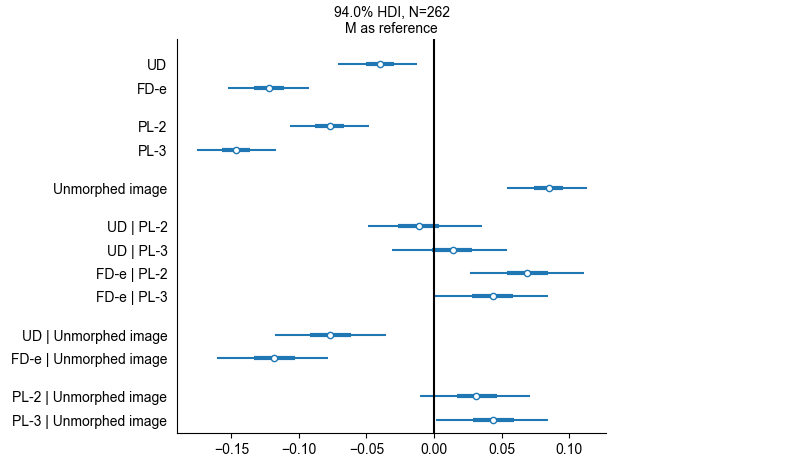

In [29]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 12
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
# c.add_text("a", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("b", Point(.52, 0.97), weight="bold", size=font_size)
           
# titles
formula = 'correct_flt ~ task * difficulty * target_loc_simple + (1|userID)'
formula_FM = 'correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)'
titles = [f"Posterior distributions in Dataset 3 for {formula}"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
# c.add_text(titles[1], Point(.55, 0.48), size=font_size)
for title in titles:
    print(title)


left_offset = 4.5
top_offset = 1
bottom_offset = 1.#1.2

hsb=.7
vsb=.3

# ### GRID
# # top row
c.add_grid(["interactions_FM"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-4.6, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"))

### plot
az.plot_forest(
    FMP_cue_stim_interaction_baselineFM_inference_data_dict[formula_FM],
    var_names=["C(task, levels=base_lvl)", "difficulty", "target_loc_simple", "C(task, levels=base_lvl):difficulty", "C(task, levels=base_lvl):target_loc_simple", "difficulty:target_loc_simple"],
    combined=True,
    ax=c.ax("interactions_FM"),
)


# update y ticks
c.ax("interactions_FM").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions_FM").get_yticklabels()
])

# c.ax("interactions_FM").set_ylabel('Interaction terms')

# add N to the title
c.ax("interactions_FM").set_title(f'{c.ax("interactions_FM").get_title()}, N={FMP_cue_stim_interaction_baselineFM_inference_data_dict[formula_FM]["posterior"]["userID__factor_dim"].size}\nM as reference')


for ax in c.axes.values():
    sns.despine(ax=ax)
    ax.axvline(0, c='k')


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_6.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_6.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 7
[top](#top)

### Bayesian inference - FMP cue stimulus
[top](#top)

In [30]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_inference_data_dict = pickle.load(f)
    
with open(opj(path_data, 'model_inference_data', 'FMP_Figure_4_cue_stim_baselineMath_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_baselineFM_inference_data_dict = pickle.load(f)


FMP_cue_stim_inference_data_dict#['correct_flt ~ task * difficulty + (1|userID)']

{'dataset_3_other': {'correct_flt ~ task * difficulty + (1|userID)': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data,
  'correct_flt ~ task + difficulty + (1|userID)': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data},
 'dataset_3_target_0': {'correct_flt ~ task * difficulty + (1|userID)': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data,
  'correct_flt ~ task + difficulty + (1|userID)': Inference data with groups:
  	> posterior
  	> log_likelihood
  	> sample_stats
  	> observed_data}}

In [31]:
FMP_cue_stim_inference_data_dict.keys()

dict_keys(['dataset_3_other', 'dataset_3_target_0'])

In [32]:
model_name_dic = {
    'correct_flt ~ task * difficulty + (1|userID)':'Interaction Model',
    'correct_flt ~ task + difficulty + (1|userID)':'No Interaction Model',   
}

FMP_cue_stim_model_compare_dic = {}

for d in FMP_cue_stim_inference_data_dict.keys():
    # create the model comparison
    df_compare_tmp = az.compare(FMP_cue_stim_inference_data_dict[d])

    # rename the models
    df_compare_tmp = df_compare_tmp.reset_index().rename(columns={'index':'formula'})
    df_compare_tmp['model_name'] = df_compare_tmp['formula'].replace(model_name_dic)
    # add dataset label
    df_compare_tmp['cue_stimulus'] = d
    
#     df_compare_tmp.set_index('model_name', inplace=True)

    FMP_cue_stim_model_compare_dic[d] = df_compare_tmp.copy()
    
df_FMP_cue_stim_model_compare = pd.concat(FMP_cue_stim_model_compare_dic).reset_index(drop=True)
# add statistical significance
for p_val in [0.05, 0.01, 0.001]:
    df_FMP_cue_stim_model_compare[f'two-tail_{str(p_val).split(".")[-1]}'] = df_FMP_cue_stim_model_compare['elpd_diff'] > df_FMP_cue_stim_model_compare['dse']*get_z_value(p_val)

df_FMP_cue_stim_model_compare

,formula,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,model_name,cue_stimulus,two-tail_05,two-tail_01,two-tail_001
0,correct_flt ~ task * difficulty + (1|userID),0,269.700257,195.086294,0.000000,0.670010,36.280176,0.000000,False,log,Interaction Model,dataset_3_other,False,False,False
1,correct_flt ~ task + difficulty + (1|userID),1,267.185368,190.783338,2.514889,0.329990,36.113914,3.872800,False,log,No Interaction Model,dataset_3_other,False,False,False
2,correct_flt ~ task * difficulty + (1|userID),0,1580.571772,207.951379,0.000000,0.858863,36.801307,0.000000,False,log,Interaction Model,dataset_3_target_0,False,False,False
3,correct_flt ~ task + difficulty + (1|userID),1,1567.696461,205.023743,12.875312,0.141137,36.956116,5.996525,False,log,No Interaction Model,dataset_3_target_0,True,False,False


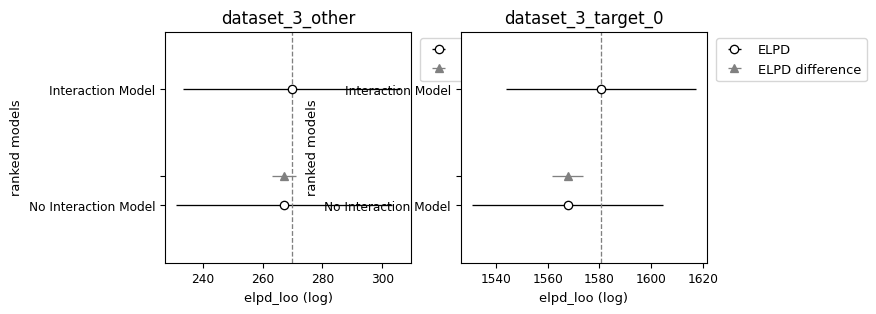

In [33]:
fig, axs = plt.subplots(1,2, figsize=(7,3))

for d, ax in zip(df_FMP_cue_stim_model_compare['cue_stimulus'].unique(), axs.flatten()):
    
    az.plot_compare(df_FMP_cue_stim_model_compare.loc[df_FMP_cue_stim_model_compare['cue_stimulus']==d].set_index('model_name'), 
                    insample_dev=False, ax=ax)
    ax.set_title(d)
    
    

/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/3493386267.py:18: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles#legend_handles


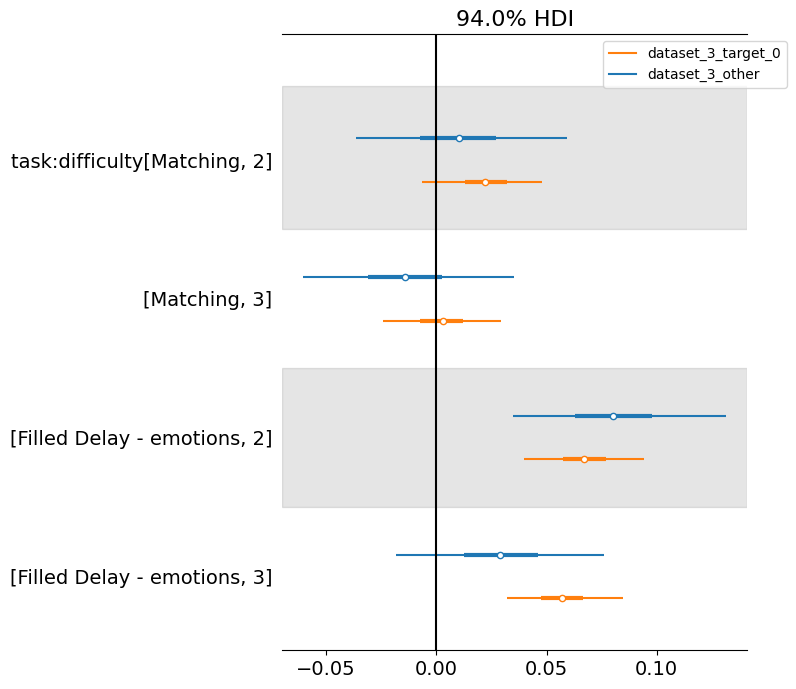

In [34]:
fig, ax = plt.subplots(figsize=(6, 8))
az.plot_forest(
    (list(FMP_cue_stim_inference_data_dict['dataset_3_other'].values())+\
    list(FMP_cue_stim_inference_data_dict['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_cue_stim_inference_data_dict.keys()],
    var_names=["task:difficulty"],
    combined=True,
#     figsize=(12, 10)
    ax=ax
);

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legendHandles#legend_handles
ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.1, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

#### with FM as baseline

{'name': 'Arial'}
Model comparison for original and morphed cue stimulus
Interactions for Dataset 3


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/661051013.py:107: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles


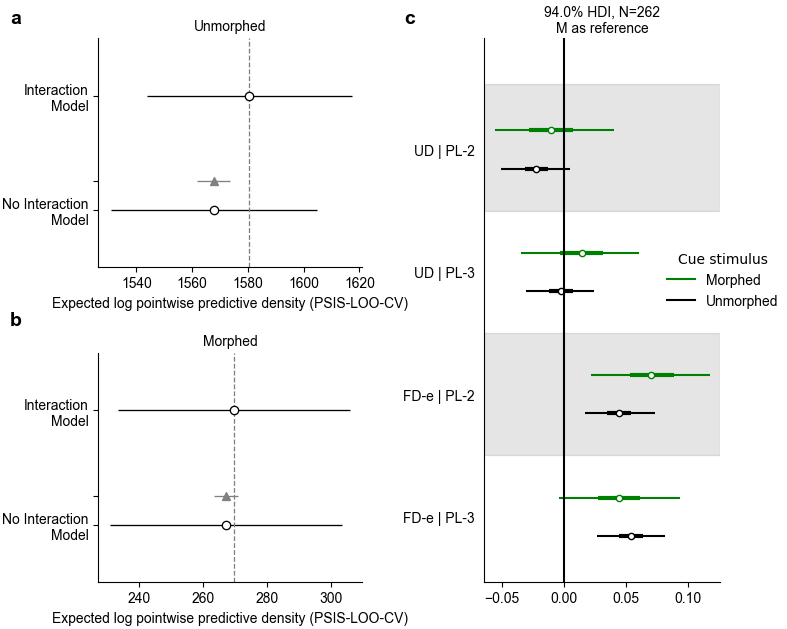

In [35]:
location_order = ['dataset_3_target_0', 'dataset_3_other']
location_rename_dic = {
    'dataset_3_target_0': 'Unmorphed',
    'dataset_3_other': 'Morphed',
}

# check that the N is the same
assert FMP_cue_stim_inference_data_dict['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size == FMP_cue_stim_inference_data_dict['dataset_3_target_0']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size
N_cue_stim = FMP_cue_stim_inference_data_dict['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size

# check it's the same for the other dataset as well
assert N_cue_stim == FMP_cue_stim_baselineFM_inference_data_dict['dataset_3_other']['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size == FMP_cue_stim_baselineFM_inference_data_dict['dataset_3_target_0']['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size


# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 16
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.97), weight="bold", size=font_size)
c.add_text("c", Point(.52, 0.97), weight="bold", size=font_size)
c.add_text("b", Point(.02, 0.49), weight="bold", size=font_size)
# c.add_text("d", Point(.49, 0.49), weight="bold", size=font_size)
           
# titles
titles = ["Model comparison for original and morphed cue stimulus", "Interactions for Dataset 3"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
# c.add_text(titles[1], Point(.55, 0.48), size=font_size)
for title in titles:
    print(title)


left_offset = 2.5
top_offset = 1
bottom_offset = 1.2

hsb=2.2
# vsb=-.4
vsb=-.2

# ### GRID
# # top row
c.add_grid(["original", "morphed"], 2, Point(left_offset, bottom_offset, "cm"), Point(a//2-vsb-1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["interaction_FM"], 1, Point(left_offset+a//2+vsb, bottom_offset, "cm"), Point(a-1.7, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"))

### plot
## left panels
for d, ax_name in zip(location_order, ["original", "morphed"]):
    
    az.plot_compare(df_FMP_cue_stim_model_compare.loc[df_FMP_cue_stim_model_compare['cue_stimulus']==d].set_index('model_name'), 
                    insample_dev=False, plot_ic_diff=True, ax=c.ax(ax_name))
    
    c.ax(ax_name).legend_.remove()
    c.ax(ax_name).set_xlabel('Expected log pointwise predictive density (PSIS-LOO-CV)')
    c.ax(ax_name).set_yticklabels([x.get_text().replace(' Model', '\nModel') for x in c.ax(ax_name).get_yticklabels()])

    c.ax(ax_name).set_title(location_rename_dic[d])

# add the last mark on the x-axis
c.ax("original").set_xlim(right=1621)

## right
az.plot_forest(
    (list(FMP_cue_stim_baselineFM_inference_data_dict['dataset_3_other'].values())+\
    list(FMP_cue_stim_baselineFM_inference_data_dict['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_cue_stim_baselineFM_inference_data_dict.keys()],
    var_names=["C(task, levels=base_lvl):difficulty"],
    combined=True,
    ax=c.ax("interaction_FM"),
    colors=['g', 'k'],
)

# add the 0 line
c.ax("interaction_FM").axvline(0, c='k')
# update y ticks
c.ax("interaction_FM").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interaction_FM").get_yticklabels()
])
# add N to the title
c.ax("interaction_FM").set_title(f'{c.ax("interaction_FM").get_title()}, N={N_cue_stim}\nM as reference')


# manually adjust the legend, there is some weird bug
legend = c.ax("interaction_FM").get_legend()
labels = [] if legend is None else [location_rename_dic[str(x._text)] for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
c.ax("interaction_FM").legend(handles[::-1], labels[::-1], title='Cue stimulus', loc="upper right", 
                           bbox_to_anchor=(1.3, .63), frameon=False)


for ax in c.axes.values():
    sns.despine(ax=ax)



# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_7.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_7.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 8
[top](#top)

### Bayesian inference - FMP Math
[top](#top)

In [36]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_math_inference_data_dict.pkl'), 'rb') as f:
    FMP_math_inference_data_dict = pickle.load(f)

    
with open(opj(path_data, 'model_inference_data', 'FMP_math_baselineFM_inference_data_dict.pkl'), 'rb') as f:
    FMP_math_inference_baselineFM_data_dict = pickle.load(f)


In [37]:
FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)']

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [38]:
model_name_dic = {
    'correct_flt ~ task * difficulty + (1|userID)':'Interaction Model',
    'correct_flt ~ task + difficulty + (1|userID)':'No Interaction Model',   
}

# create the model comparison
df_compare_formulas_math = az.compare(FMP_math_inference_data_dict)

# rename the models
df_compare_formulas_math = df_compare_formulas_math.reset_index().rename(columns={'index':'formula'})
df_compare_formulas_math['model_name'] = df_compare_formulas_math['formula'].replace(model_name_dic)
df_compare_formulas_math.set_index('model_name', inplace=True)

# add statistical significance
for p_val in [0.05, 0.01, 0.001]:
    df_compare_formulas_math[f'two-tail_{str(p_val).split(".")[-1]}'] = df_compare_formulas_math['elpd_diff'] > df_compare_formulas_math['dse']*get_z_value(p_val)


df_compare_formulas_math

,formula,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,two-tail_05,two-tail_01,two-tail_001
model_name,,,,,,,,,,,,,
No Interaction Model,correct_flt ~ task + difficulty + (1|userID),0,1355.197884,132.580711,0.000000,1.0,30.604177,0.000000,False,log,False,False,False
Interaction Model,correct_flt ~ task * difficulty + (1|userID),1,1351.550631,138.653361,3.647252,0.0,30.852211,2.683291,False,log,False,False,False


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

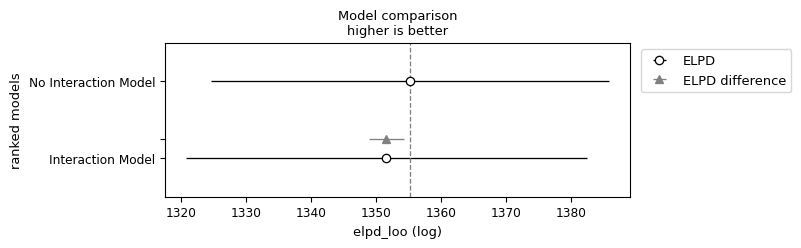

In [39]:
az.plot_compare(df_compare_formulas_math, insample_dev=False)

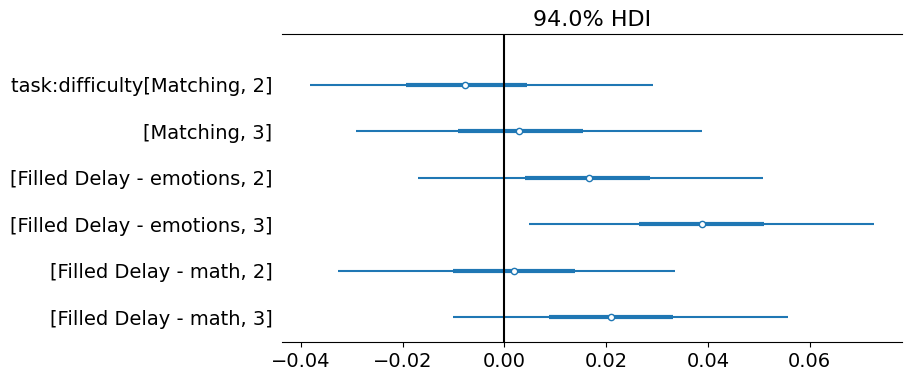

In [40]:
az.plot_forest(FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'], 
               var_names=["task:difficulty"], combined=True, figsize=(8, 4))
plt.axvline(0, c='k');


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/1740640000.py:14: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles


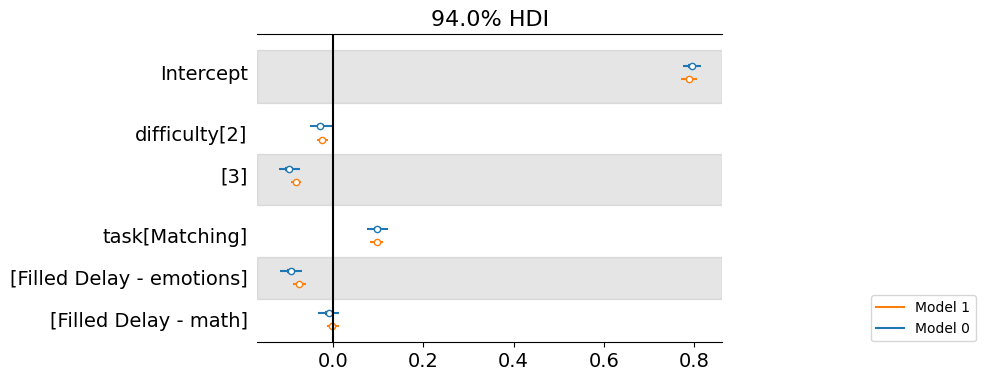

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
az.plot_forest(
    list(FMP_math_inference_data_dict.values()),
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legendHandles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1.56, -.02), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

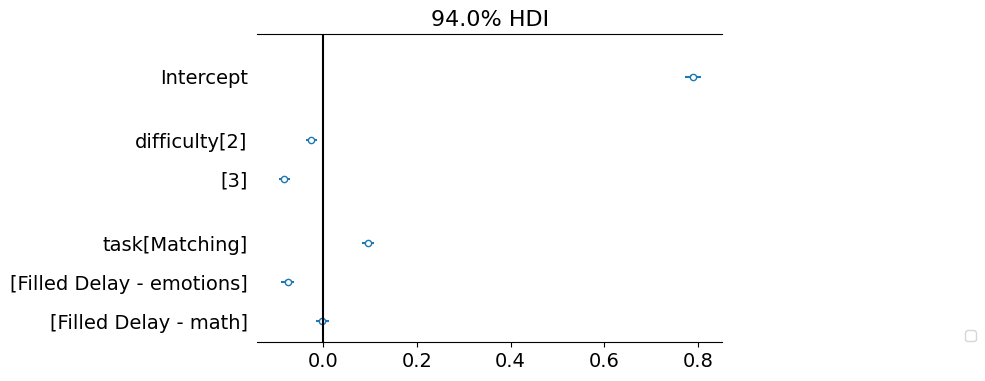

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
az.plot_forest(
    FMP_math_inference_data_dict['correct_flt ~ task + difficulty + (1|userID)'],
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legendHandles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1.56, -.02), ncols=1)
plt.show()

expected log pointwise predictive density (ELPD) The ELPD is estimated either by Pareto smoothed importance sampling leave-one-out
cross-validation (LOO) -> PSIS-LOO-CV

#### With FM as baseline

{'name': 'Arial'}
Accuracy per task
d' per task
Overal accuracy
Overall d'


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/1868337853.py:109: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles
/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_35566/1868337853.py:137: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = [] if legend is None else legend.legendHandles #legend.legend_handles


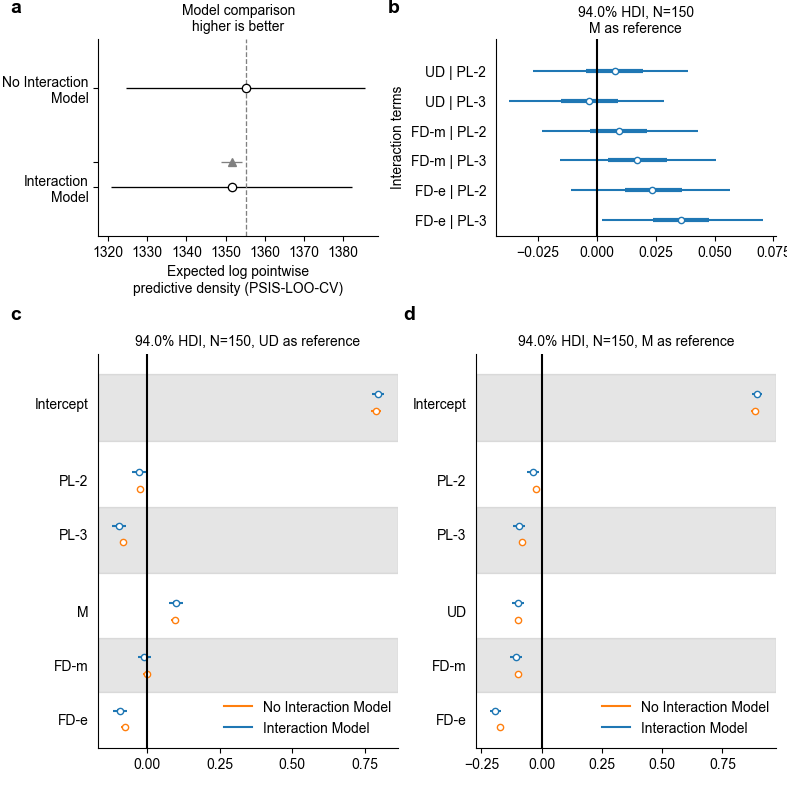

In [43]:
# define canvas

from cand import Canvas, Vector, Point
import matplotlib.ticker as ticker

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 16+4#9
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.99), weight="bold", size=font_size)
c.add_text("b", Point(.5, 0.99), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.60), weight="bold", size=font_size)
c.add_text("d", Point(.52, 0.60), weight="bold", size=font_size)
# c.add_text("d", Point(.49, 0.49), weight="bold", size=font_size)
           
# titles
titles = ["Accuracy per task", "d' per task", "Overal accuracy", "Overall d'"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
# c.add_text(titles[1], Point(.55, 0.48), size=font_size)
for title in titles:
    print(title)


left_offset = 2.5
top_offset = 1
middle = 13
bottom_offset = 1

hsb=2.7
vsb=2
hsb_middle = 1

# ### GRID
# # top row
c.add_grid(["comparison", "interaction_FM"], 1, Point(left_offset, middle+hsb_middle, "cm"), Point(a-.3, b-top_offset, "cm"), spacing=Vector(vsb+1, hsb, "cm"), unitname="grid")
c.add_grid(["main_effect", "main_effect_FM"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-.3, middle-top_offset-hsb_middle, "cm"), spacing=Vector(vsb, hsb, "cm"))

### plot
N_math = FMP_math_inference_data_dict["correct_flt ~ task + difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size

## top left
az.plot_compare(df_compare_formulas_math, plot_ic_diff=True, insample_dev=False, ax=c.ax("comparison"))
# c.ax("comparison").legend(loc="upper right", bbox_to_anchor=(1.1,1.05), frameon=False)
c.ax("comparison").legend_.remove()
c.ax("comparison").set_xlabel('Expected log pointwise\npredictive density (PSIS-LOO-CV)')
c.ax("comparison").set_yticklabels([x.get_text().replace(' Model', '\nModel') for x in c.ax("comparison").get_yticklabels()])
c.ax("comparison").xaxis.set_major_locator(ticker.MultipleLocator(10))

## top right
az.plot_forest(FMP_math_inference_baselineFM_data_dict['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)'], 
               var_names=["C(task, levels=base_lvl):difficulty"], combined=True, ax=c.ax("interaction_FM"))
c.ax("interaction_FM").axvline(0, c='k')

# go over the y ticks to change them and clean them
# to map the abbreviations: retrieve the value associated with the specified key (word.strip()) from the dictionary, 
# if it isn't there, use the word itself
c.ax("interaction_FM").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    for x in c.ax("interaction_FM").get_yticklabels()
])
c.ax("interaction_FM").set_ylabel('Interaction terms')
# add N to the title
c.ax("interaction_FM").set_title(f'{c.ax("interaction_FM").get_title()}, N={N_math}\nM as reference')
c.ax("interaction_FM").xaxis.set_major_locator(ticker.MultipleLocator(0.025))


########## bottom
## left
az.plot_forest(
    list([FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'], FMP_math_inference_data_dict['correct_flt ~ task + difficulty + (1|userID)']]),
    model_names=['Interaction Model', 'No Interaction Model'],
    var_names=["Intercept", "difficulty", "task"],
    # coords={"task_dim": ["face matching", "math", "interference"]},  # Specify dimensions
    coords={"task_dim": ['Matching', 'Filled Delay - math', 'Filled Delay - emotions']}, # specify dimensions
    combined=True,
    ax=c.ax("main_effect")
)

# add the 0 line
c.ax("main_effect").axvline(0, c='k')
# update y ticks
c.ax("main_effect").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("main_effect").get_yticklabels()
])
# add N to the title
c.ax("main_effect").set_title(f'{c.ax("main_effect").get_title()}, N={N_math}, UD as reference')


# manually adjust the legend, there is some weird bug
legend = c.ax("main_effect").get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
c.ax("main_effect").legend(handles, labels, loc="lower right", bbox_to_anchor=(1.02, 0), frameon=False)


## right
az.plot_forest(
    list([FMP_math_inference_baselineFM_data_dict['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)'], FMP_math_inference_baselineFM_data_dict['correct_flt ~ C(task, levels=base_lvl) + difficulty + (1|userID)']]),
    model_names=['Interaction Model', 'No Interaction Model'],
    var_names=["Intercept", "difficulty", "C(task, levels=base_lvl)"],
#     coords={"task_dim": ["face matching", "math", "interference"]},  # Specify dimensions
    combined=True,
    ax=c.ax("main_effect_FM")
)

# add the 0 line
c.ax("main_effect_FM").axvline(0, c='k')
# update y ticks
c.ax("main_effect_FM").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("main_effect_FM").get_yticklabels()
])
# add N to the title
c.ax("main_effect_FM").set_title(f'{c.ax("main_effect_FM").get_title()}, N={N_math}, M as reference')

# manually adjust the legend, there is some weird bug
legend = c.ax("main_effect").get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
c.ax("main_effect_FM").legend(handles, labels, loc="lower right", bbox_to_anchor=(1.02, 0), frameon=False)



for ax in c.axes.values():
    sns.despine(ax=ax)



# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()

c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_8.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_8.pdf'), dpi=300)#, bbox_inches="tight")

In [44]:
FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'].posterior['task'].coords['task_dim'].values #.data_vars#.var_names

array(['Matching', 'Filled Delay - emotions', 'Filled Delay - math'],
      dtype='<U23')

In [45]:
FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'].posterior['task:difficulty'].coords['task:difficulty_dim'].values


array(['Matching, 2', 'Matching, 3', 'Filled Delay - emotions, 2',
       'Filled Delay - emotions, 3', 'Filled Delay - math, 2',
       'Filled Delay - math, 3'], dtype='<U26')

## SI Figure 9
[top](#top)

In [46]:
# load all dataframes
df_dic_mem = {}

# for file in os.listdir(path_datasets):
for file in ['FMP_memory_dataset_1b.csv', 'FMP_memory_dataset_2.csv', 'FMP_memory_dataset_3.csv']:
    f = file.replace('FMP_memory_', '').replace('.csv', '')
    df_dic_mem[f] = pd.read_csv(os.path.join(path_datasets, file))
    
    df_dic_mem[f]["Experiment"] = f
        

    # clean
    df_dic_mem[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic_mem[f].columns:
        df_dic_mem[f].drop('Unnamed: 0', inplace=True, axis=1)

### Compute d'
[top](#top)

In [47]:
# First we need to deal with randomised matched S experiment where there are not the same 
# numbers of old/new stimuli per participant, so the ratios has to be computed separately

# group the data by userID and familiarity
grouped_data = df_dic_mem['dataset_2'].loc[
    ~df_dic_mem['dataset_2']['familiarity'].isna(),
    ['familiarity', 'userID']
].groupby(['userID', 'familiarity']).size().unstack(fill_value=0)

# initialise a dictionary to store the results
df_results_dprime = pd.DataFrame({})

# iterate over each userID
for userID in grouped_data.index:
    c = grouped_data.loc[userID, 'old']
    d = grouped_data.loc[userID, 'new']
    a = c / (c + d)
    b = d / (c + d)
    
    # apply the calculate_d_prime function
    result = calculate_d_prime(
        df_dic_mem['dataset_2'].loc[(~df_dic_mem['dataset_2']['familiarity'].isna())&(df_dic_mem['dataset_2']['userID']==userID)],
        a, b, c, d, col='correct_memory_check_flt', c=True, beta=True
    )
    
    # store the result for the current userID
    df_results_dprime = pd.concat([df_results_dprime, pd.DataFrame(result)])

df_results_dprime.reset_index(inplace=True)

df_results_dprime['task'] = 'dataset_2'



# add all tasks
for f in ['dataset_1b', 'dataset_3']:
    tmp = pd.DataFrame(
        calculate_d_prime(df_dic_mem[f].loc[(~df_dic_mem[f]['familiarity'].isna())&(df_dic_mem[f]['task'] =='memory-confidence')], 
                      0.5, 0.5, 30, 30, col='correct_memory_check_flt', c=True, beta=True)
    ).reset_index()
    tmp['task'] = f
    
    df_results_dprime = pd.concat([df_results_dprime,tmp])

df_results_dprime.reset_index(inplace=True, drop=True)

df_results_dprime


,userID,d_prime,beta,c,task
0,s_10,0.389973,1.163212,0.387681,dataset_2
1,s_1003,-0.260927,1.102930,-0.375470,dataset_2
2,s_1036,1.185061,0.495501,-0.592531,dataset_2
3,s_104,-0.343504,1.121641,-0.334182,dataset_2
4,s_1047,1.155739,0.386343,-0.822876,dataset_2
...,...,...,...,...,...
591,s_984,0.491721,1.041878,0.083431,dataset_3
592,s_992,0.929470,1.134158,0.135444,dataset_3
593,s_993,1.106112,0.949212,-0.047123,dataset_3
594,s_994,0.403691,1.503026,1.009387,dataset_3


#### Map the first task on the data
[top](#top)

In [48]:
df_user_task_dict = pd.DataFrame()

for i,f in enumerate(df_results_dprime.task.unique()):
    if f=='PB13':
        order=18
    else:
        order=1
    # get the first task per user
    user_task_dict = df_dic[f].loc[df_dic[f]["order"]==order].groupby('userID')['task'].first()
    
    df_user_task_dict = pd.concat([df_user_task_dict,user_task_dict])
    
df_results_dprime['first_task'] = df_results_dprime['userID'].map(df_user_task_dict.to_dict()[0]).replace('perc', 'perception')

# check
df_results_dprime[df_results_dprime['first_task'].isna()]

,userID,d_prime,beta,c,task,first_task


{'name': 'Arial'}
d' versus accuracy in datasets
dataset_1b
dataset_2
dataset_3


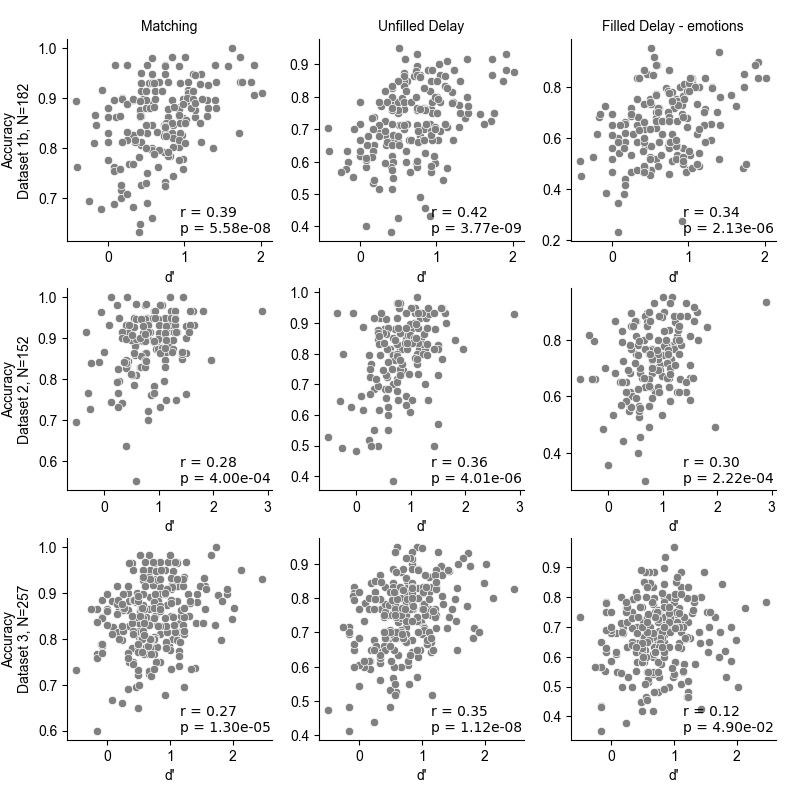

In [49]:
##
experiment2use = ['dataset_1b', 'dataset_2', 'dataset_3']
# todo do it elsewhere
experiments_rename_dic = {'dataset_1b':'Dataset 1b', 'dataset_2':'Dataset 2', 'dataset_3': 'Dataset 3'}
palette_memory = 'Greys'

# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 20
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("b", Point(.49, 0.98), weight="bold", size=font_size)
           
# titles
titles = ["d' versus accuracy in datasets"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 1.7
top_offset = 1
middle_bottom = 9
hspace_between_plots = 2.8
bottom_offset = 1.2

hsb=1.2
vsb=1.2

# ### GRID
# # top row
c.add_grid([f"corr_{t}_{d}" for d in experiment2use for t in hue_order], 3, Point(left_offset, bottom_offset, "cm"), Point(a-.3, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")


############
# correlation

# all 4 datasets together
for d_name in experiment2use:
    print(d_name)
    # get scores of the concatenated all datasets
    tmp = df_dic[d_name].groupby(['userID', 'task']).correct_flt.mean().reset_index()

    # add memory
    df_FMP_scores = pd.concat([tmp, df_results_dprime.loc[df_results_dprime["task"]==d_name].rename(columns={"d_prime":"correct_flt"})])
    # rename the 'experiment' that is called 'task' in this dataset with the correct label
    df_FMP_scores['task'] = df_FMP_scores['task'].str.replace(d_name, 'd_prime')

    # create a wide format 
    df_FMP_scores = df_FMP_scores.pivot(index='userID', columns='task', values='correct_flt').reset_index().dropna().rename(columns={"correct_flt":"d_prime"})

    for t in hue_order:
        sns.scatterplot(data=df_FMP_scores, x='d_prime', y=t, ax=c.ax(f"corr_{t}_{d_name}"),color='gray')

        if d_name=='dataset_1b':
            c.ax(f"corr_{t}_{d_name}").set_title(f"{t}")
        c.ax(f"corr_{t}_{d_name}").set_xlabel("d'")
        if t == 'Matching':
            c.ax(f"corr_{t}_{d_name}").set_ylabel(f"Accuracy\n{experiments_rename_dic[d_name]}, N={df_FMP_scores.userID.unique().size}")
        else:
            c.ax(f"corr_{t}_{d_name}").set_ylabel("")


        sns.despine(ax=c.ax(f"corr_{t}_{d_name}"))

        label_correlation(df_FMP_scores['d_prime'], df_FMP_scores[t], c.ax(f"corr_{t}_{d_name}"), xy=(.55, .04))


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_9.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_9.pdf'), dpi=300)#, bbox_inches="tight")

## SI Figure 10
[top](#top)

This figure is done separately.

## SI Figure 11
[top](#top)

Participants demo

In [50]:
import geopandas

# load dataset for geopandas
world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
world["name"].replace({"Czechia":"Czech Republic", "United States of America":"United States"}, inplace=True)

# load data
df_participants = pd.read_csv('../Data/demographic_data/demographics_all_subjects.csv')

# select only people who have everything
# df_participants = df_participants[df_participants["userID"].isin(all_subjects)]

df_participants

,userID,Age,Sex,Ethnicity simplified,Country of birth,Country of residence,Nationality,Language
0,s_1,28,Female,Other,Mexico,Mexico,Mexico,English
1,s_2,32,Female,White,United Kingdom,United Kingdom,United Kingdom,English
2,s_3,19,Male,NaN,Portugal,Portugal,Portugal,Portuguese
3,s_4,24,Male,NaN,Poland,Poland,Poland,Polish
4,s_5,29,Male,NaN,United States,United States,United States,English
...,...,...,...,...,...,...,...,...
1225,s_1327,31,Male,White,United Kingdom,United Kingdom,United Kingdom,English
1226,s_1328,28,Female,White,United Kingdom,United Kingdom,United Kingdom,English
1227,s_1329,45,Male,Black,South Africa,South Africa,South Africa,English
1228,s_1330,19,Male,White,Poland,Poland,Poland,Polish


In [51]:
# create a helper plot function

from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_bar_map(data, world, var, ax, ax2, cmap="viridis", gridlines=True, y_labelsize=10, barlabel_fontsize=12):
    colours = sns.color_palette(cmap, n_colors=len(data.unique()))

    # count the country values
    vc = data.value_counts().reset_index()
    vc.columns = ["label", "count"]
    # and sort them first based on the count and then alphabeticaly
    vc = vc.sort_values(by=["count", "label"], ascending=[False, True])
    
    # horizontal
    # ax.barh(data.value_counts().index, data.value_counts(), color=colours)
    ax.barh(vc["label"], vc["count"], color=colours)

    # remove axes splines
    for s in ['top', 'bottom', 'left', 'right']:
        ax.spines[s].set_visible(False)

    # remove ticks
    ax.yaxis.set_ticks_position('none')
    ax.xaxis.set_ticks_position('none')
    # remove labels
    ax.set_xticklabels([])
    # reduce the size of y-tick labels
    ax.tick_params(axis='y', labelsize=y_labelsize)
    print(type(ax))

    # add padding between axes and labels
    ax.xaxis.set_tick_params(pad = 5)
#     ax.yaxis.set_tick_params(pad = 10)

    # add x gridlines
    if gridlines:
        ax.grid(axis='x', color ='grey',
                linestyle ='-.', linewidth = 0.4,
                alpha = 0.3)

    # change the spacing to be every 5
    # https://stackoverflow.com/a/56180359/12281892
    ax.xaxis.set_major_locator(MultipleLocator(5))

    # show top values
    ax.invert_yaxis()

    # add annotation to bars
    for i in ax.patches:
    #     print(i.get_x(), i.get_y())
        ax.text(i.get_width()+0.2, i.get_y()+0.6,
                 int(i.get_width()),
                 fontsize = barlabel_fontsize, fontweight ='bold',
                 color ='gray')

    # create legend for the country map
    # divider = make_axes_locatable(ax2)
    # cax = divider.append_axes("right", size="5%", pad=0.1)    
    # plot the country map    
    world.plot(column=var, ax=ax2, legend=True, 
    #            cax=cax,
               legend_kwds={'label': "Number of participants per country",
                            'orientation': "horizontal",
                            'pad':0.01},
               # have grey with no people
               missing_kwds={'color': 'lightgrey'},
               cmap=cmap+"_r")

    # remove the axis
    ax2.set_axis_off()

<class 'matplotlib.axes._axes.Axes'>


/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


<class 'matplotlib.axes._axes.Axes'>


/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


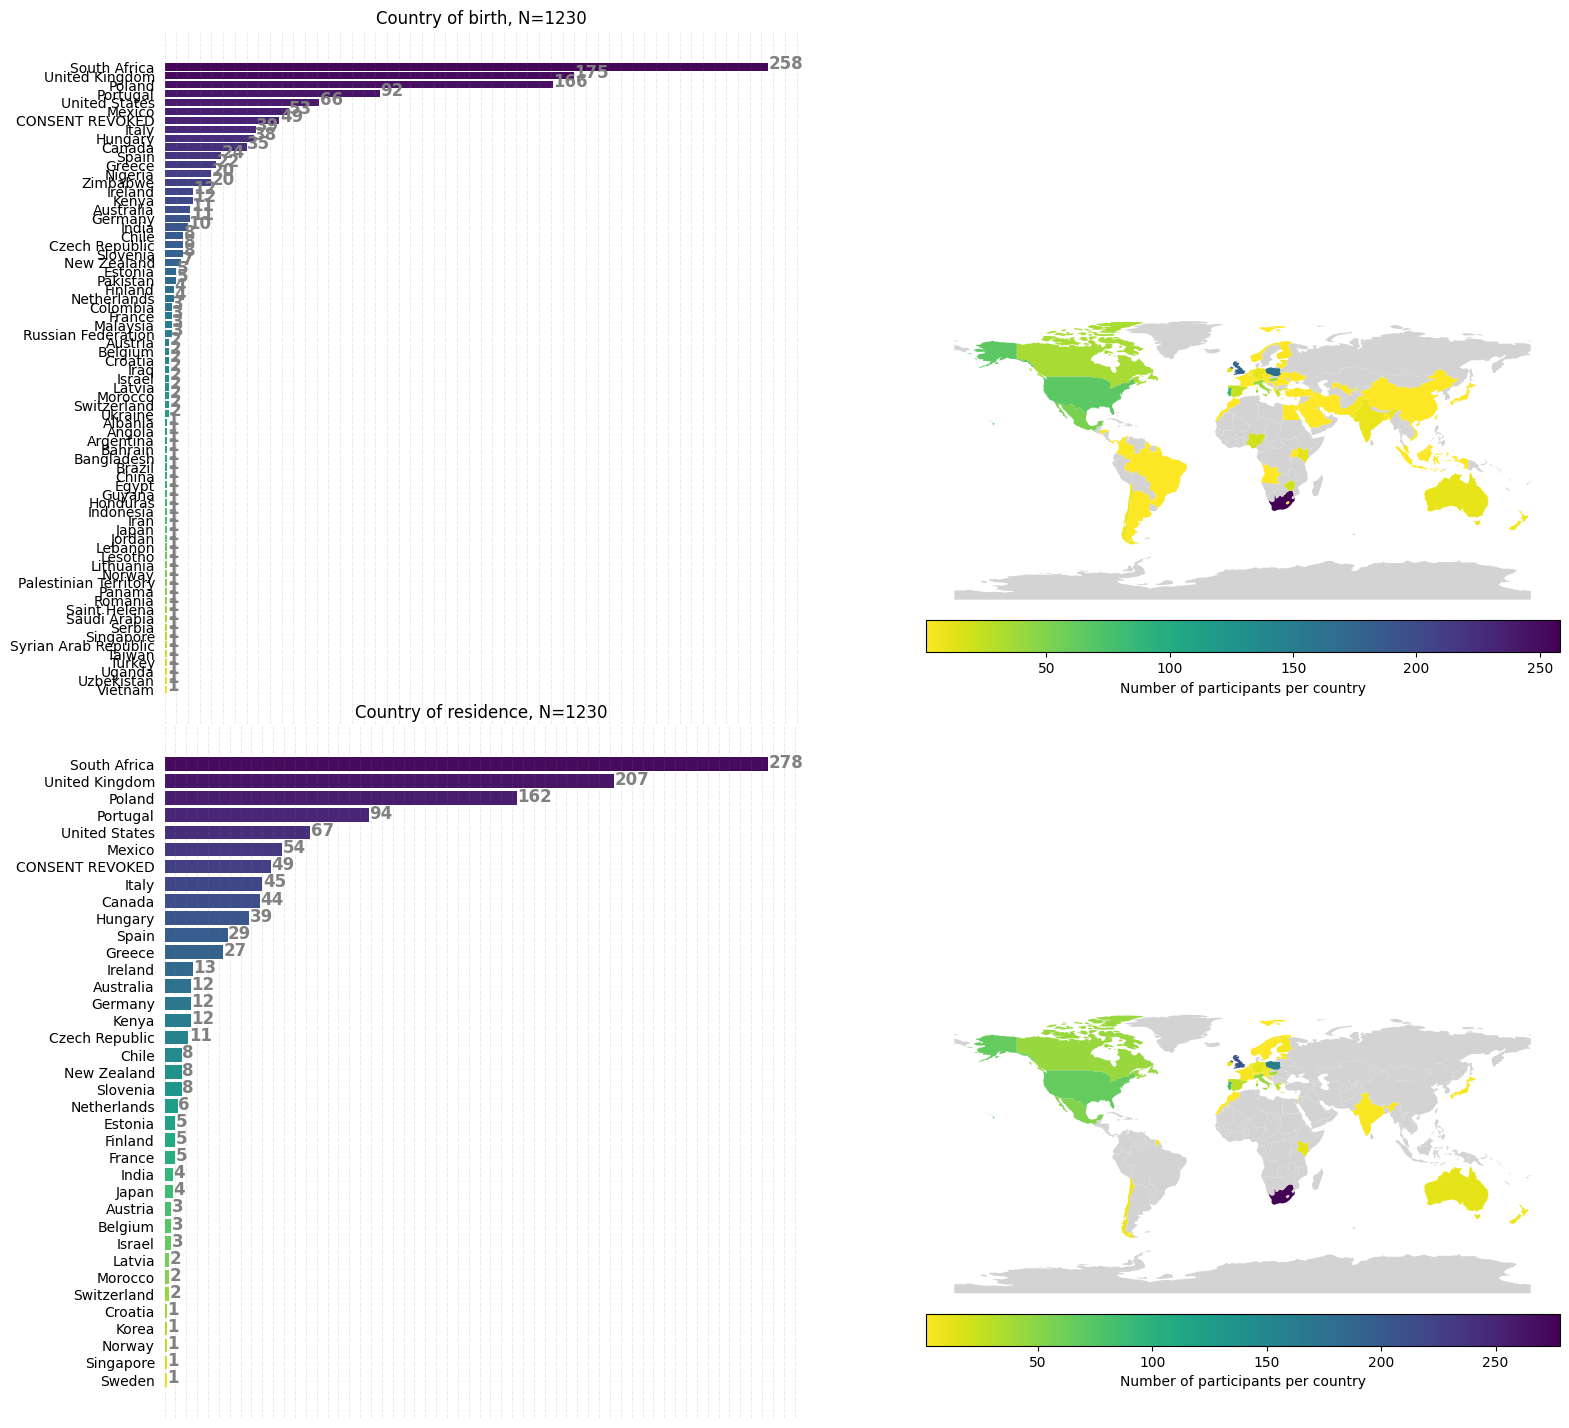

In [52]:
fig, (ax1, ax2) = plt.subplots(2,2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.002)

countries = ["Country of birth", "Country of residence"]

for var, (ax_t,ax_b) in zip(countries, [ax1,ax2]):
    # select data
    data = df_participants.loc[~df_participants[var].isin(["DATA EXPIRED","DATA_EXPIRED"]),var]

    # create mapping
    world[var] = world["name"].map(data.value_counts())#.fillna(0)


    plot_bar_map(data, world, var, ax_t, ax_b, cmap="viridis")


#     ax_t.set_title(f"{var}, N={len(all_subjects)}")
    ax_t.set_title(f"{var}, N={df_participants.userID.unique().size}")

    
# # ax1[0].tick_params(axis='y', labelsize=2)
# # Get current y-tick labels
# labels = ax1[0].get_yticklabels()

# # Set y-tick labels with a custom font size
# ax1[0].set_yticklabels(labels, fontsize=8)
    
plt.ylabel('')
# plt.suptitle(f"{var}, N={len(all_subjects)}", y=.88)
plt.show()    

{'name': 'Arial'}
Country of birth
Country of residence
<class 'matplotlib.axes._axes.Axes'>
<class 'matplotlib.axes._axes.Axes'>


/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/Users/jan/Do

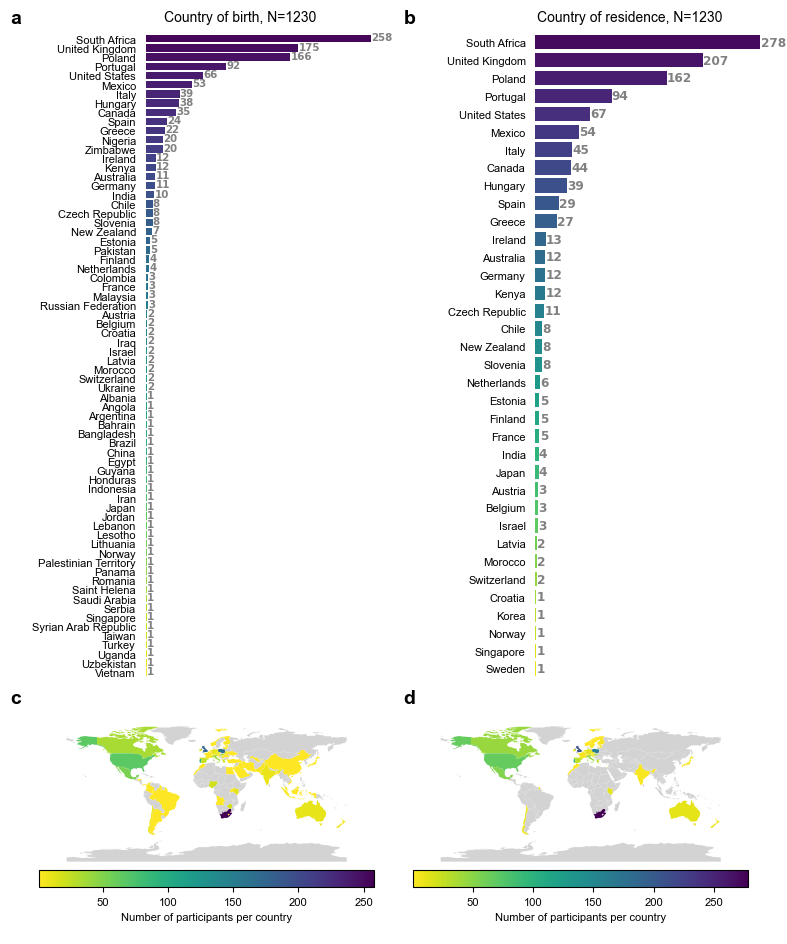

<Figure size 640x480 with 0 Axes>

In [53]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 24
# rot = 15
c = Canvas(a, b, "cm")

# set font
# c.set_font("Arial", size=10)
c.set_font("Arial", size=8)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("C)", Point(.02, 0.37), size=font_size)
c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.52, 0.98), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.26), weight="bold", size=font_size)
c.add_text("d", Point(.52, 0.26), weight="bold", size=font_size)
           
# titles
titles = ["Country of birth", "Country of residence"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
# c.add_text(titles[1], Point(.55, 0.48), size=font_size)
for title in titles:
    print(title)


left_offset = 3.7
left_offset_map = 1
top_offset = .4
middle_bottom = 6
hspace_between_plots = 0.3
bottom_offset = 1.2

hsb=1.2
vsb=3.9
vsb_map = 1

# ### GRID
# # top row
c.add_grid(["barplot_birth", "barplot_residence"], 1, Point(left_offset, middle_bottom, "cm"), Point(a-.4, b-top_offset+hspace_between_plots, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["map_birth", "map_residence"], 1, Point(left_offset_map, bottom_offset, "cm"), Point(a-left_offset_map, middle_bottom-hspace_between_plots, "cm"), spacing=Vector(vsb_map, hsb, "cm"))


######### plot
countries = ["Country of birth", "Country of residence"]

for var in ["birth", "residence"]:
    # select data
    data = df_participants.loc[~df_participants[f"Country of {var}"].isin(["DATA_EXPIRED", "DATA EXPIRED", "CONSENT REVOKED"]), 
                               f"Country of {var}"]

    # create mapping
    world[var] = world["name"].map(data.value_counts())#.fillna(0)


    plot_bar_map(data, world, var, c.ax(f"barplot_{var}"), c.ax(f"map_{var}"), 
                 cmap="viridis", gridlines=False, barlabel_fontsize=6+100/(len(set(data))), 
                 y_labelsize=1)


#     ax_t.set_title(f"{var}, N={len(all_subjects)}")
    c.ax(f"barplot_{var}").set_title(f"{var}, N={df_participants.userID.unique().size}")

    c.add_text(f"Country of {var}, N={df_participants.userID.unique().size}", Point(0.4, .98, f"axis_barplot_{var}"), size=10)
    
# # c.ax("barplot_birth").tick_params(axis='y', labelsize=2)
# # Get current y-tick labels
# labels = c.ax("barplot_birth").get_yticklabels()

# # Set y-tick labels with a custom font size
# c.ax("barplot_birth").set_yticklabels(labels, fontsize=2)

for label in c.ax("barplot_birth").get_yticklabels():
    label.set_fontsize(2)

# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_11.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, 'SI', 'Supplementary_Figure_11.pdf'), dpi=300)#, bbox_inches="tight")

In [54]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv

Author: Jan Kadlec

Last updated: Tue Jun 03 2025

Python implementation: CPython
Python version       : 3.8.6
IPython version      : 8.12.3

Compiler    : Clang 6.0 (clang-600.0.57)
OS          : Darwin
Release     : 24.5.0
Machine     : x86_64
Processor   : i386
CPU cores   : 16
Architecture: 64bit

pingouin  : 0.5.5
numpy     : 1.24.4
pandas    : 2.0.3
geopandas : 0.10.2
seaborn   : 0.13.2
sys       : 3.8.6 (v3.8.6:db455296be, Sep 23 2020, 13:31:39) 
[Clang 6.0 (clang-600.0.57)]
cand      : 0.0.2
matplotlib: 3.7.5
arviz     : 0.15.1



[top](#top)